<a href="https://colab.research.google.com/github/muxicolin/SC3021-Lab-Project/blob/main/SC3021_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Team 5, SC3021 Project***


In [ ]:
# Import relevant packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
# Load the .csv file stored in Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ***"What makes a song succeed on both Youtube and Spotify?"***

## --Analysis based on popular songs of popular artists

## **1. Hypothesis / Analysis Goal (Ask)**

**Project Background**

Music success is often measured by streaming counts on Spotify, or video views on YouTube, two dominating platforms of the music industry. However, due to their different recommendation mechanisms and user behaviors, a song that proves to be a big hit on one platform is not guaranteed to thrive on another.

In this project, we will explore popular songs that have made a breakthrough on both YouTube and Spotify, and analyze which audio characteristics contributed most to this cross-platform success, hoping to guide future artists and composers to rise in this music-craving yet media-driven world.

## **2. Data Source Identification & Exploration(Prepare)**

**Requirement Analysis**

To tackle the question, our group deems that the following aspects of a song or its MV on Spotify or YouTube need to be collected:

- **Basic Information**: Track, Artist, Release date, etc.
- **Audio Features**: Danceability, Energy, Key, Rythm, etc.(Based on information provided by Spotify API)
- **Popularity Features**: Streams on Spotify, Views on YouTube.

**List of Considered Sources**

By a throughout search on various database platforms such as Kaggle, we have collected the following datasets, among which DS1-3 will be applied, whereas DS4 has been excluded:  
[DS1: Spotify and Youtube*](https://www.kaggle.com/datasets/salvatorerastelli/spotify-and-youtube)

[DS2: 30000 Spotify Songs*](https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs)

[DS3: YouTube Top 100 Songs 2025 Dataset*](https://www.kaggle.com/datasets/vedikagupta0/youtube-top-100-songs-2025-dataset)


[DS4: Spotify Most Streamed Songs](http://kaggle.com/datasets/abdulszz/spotify-most-streamed-songs)



### **DS1: Spotify and YouTube**

**Description**

This dataset, released recently in 2023, consists of 28 columns (26 variables), and specifically records basic information and critical audio characteristics for the top 10 songs of various Spotify artists and their corresponding YouTube videos in a ".csv" file format.

In [ ]:
# Read the DS1 .csv file
ds1 = pd.read_csv('/content/drive/MyDrive/SC3021 datasets/Spotify_Youtube.csv')

display(ds1)

,Unnamed: 0,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07
3,3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On Melancholy Hill,Plastic Beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,0.689,0.739,2.0,...,https://www.youtube.com/watch?v=04mfKJWDSzI,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,Follow Gorillaz online:\nhttp://gorillaz.com \...,True,True,4.346636e+08
4,4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint Eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,0.663,0.694,10.0,...,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,True,True,6.172597e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20713,20713,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,JUST DANCE HARDSTYLE,JUST DANCE HARDSTYLE,single,spotify:track:0RtcKQGyI4hr8FgFH1TuYG,0.582,0.926,5.0,...,https://www.youtube.com/watch?v=5SHmKFKlNqI,JUST DANCE HARDSTYLE,SICK LEGEND - Topic,71678.0,1113.0,0.0,Provided to YouTube by Routenote\n\nJUST DANCE...,True,True,9.227144e+06
20714,20714,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,SET FIRE TO THE RAIN HARDSTYLE,SET FIRE TO THE RAIN HARDSTYLE,single,spotify:track:3rHvPA8lUnPBkaLyPOc0VV,0.531,0.936,4.0,...,https://www.youtube.com/watch?v=ocTH6KxllDQ,SET FIRE TO THE RAIN HARDSTYLE,SICK LEGEND - Topic,164741.0,2019.0,0.0,Provided to YouTube by Routenote\n\nSET FIRE T...,True,True,1.089818e+07
20715,20715,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,OUTSIDE HARDSTYLE SPED UP,OUTSIDE HARDSTYLE SPED UP,single,spotify:track:4jk00YxPtPbhvHJE9N4ddv,0.443,0.830,4.0,...,https://www.youtube.com/watch?v=5wFhE-HY0hg,OUTSIDE HARDSTYLE SPED UP,SICK LEGEND - Topic,35646.0,329.0,0.0,Provided to YouTube by Routenote\n\nOUTSIDE HA...,True,True,6.226110e+06
20716,20716,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,ONLY GIRL HARDSTYLE,ONLY GIRL HARDSTYLE,single,spotify:track:5EyErbpsugWliX006eTDex,0.417,0.767,9.0,...,https://www.youtube.com/watch?v=VMFLbFRNCn0,ONLY GIRL HARDSTYLE,SICK LEGEND - Topic,6533.0,88.0,0.0,Provided to YouTube by Routenote\n\nONLY GIRL ...,True,True,6.873961e+06


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Explore the Artists Involved**

In [ ]:
### Below is the original AI output from Gemini

# Prompt: count the number of unique artists in ds1 and give a list of them
unique_artists = ds1['Artist'].unique()
print(f'List of unique artists:\n{unique_artists}')
print(f'\nThe number of unique artists is: {len(unique_artists)}')


List of unique artists:
['Gorillaz' 'Red Hot Chili Peppers' '50 Cent' ... 'LE SSERAFIM' 'ThxSoMch'
 'SICK LEGEND']

The number of unique artists is: 2079


According to data extraction from DS1, we observe that it covers a wide range of artists, providing ample data for analysis.

**Exploring the Streams and Views of MVs of Each Singer**

,Artist,Total Streams
0,$NOT,1.127638e+09
1,$uicideboy$,2.126748e+09
2,(G)I-DLE,1.304212e+09
3,*NSYNC,1.427834e+09
4,070 Shake,4.647486e+08


,Artist,Total YouTube Views
0,$NOT,1.107849e+08
1,$uicideboy$,3.341351e+08
2,(G)I-DLE,1.754954e+09
3,*NSYNC,1.027833e+09
4,070 Shake,9.609936e+07


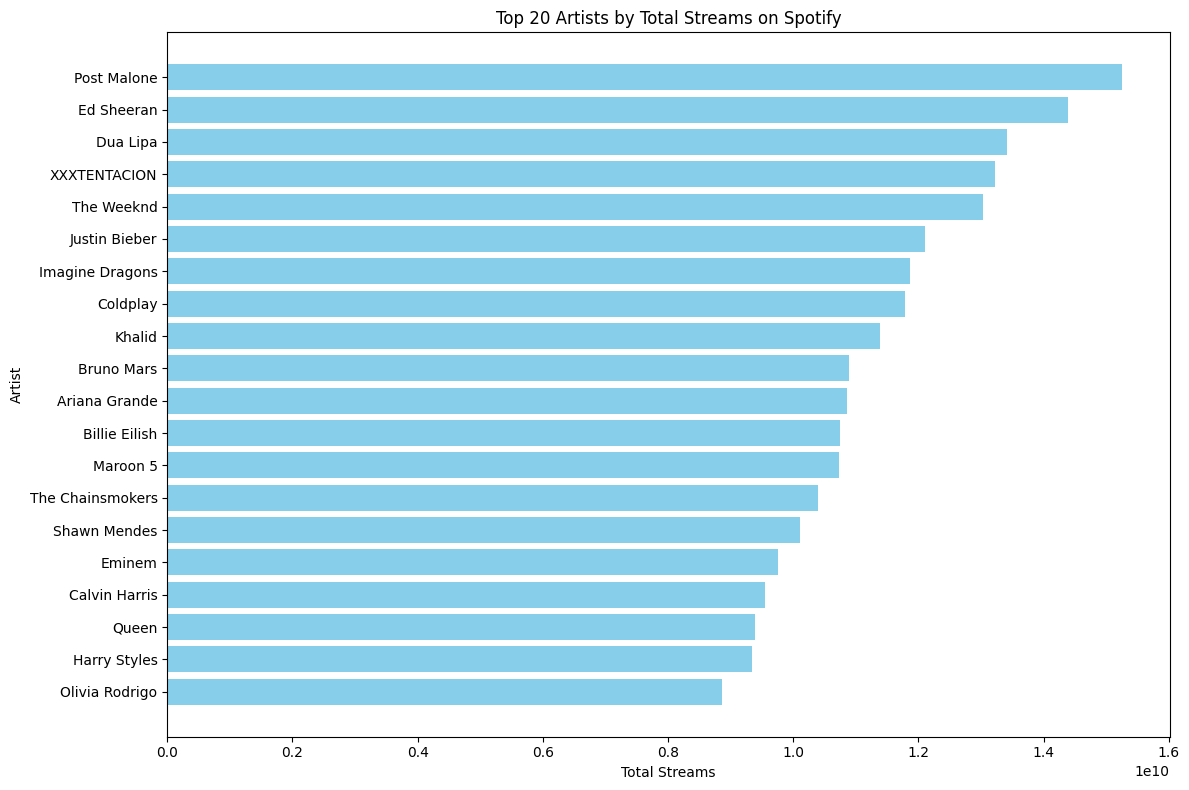

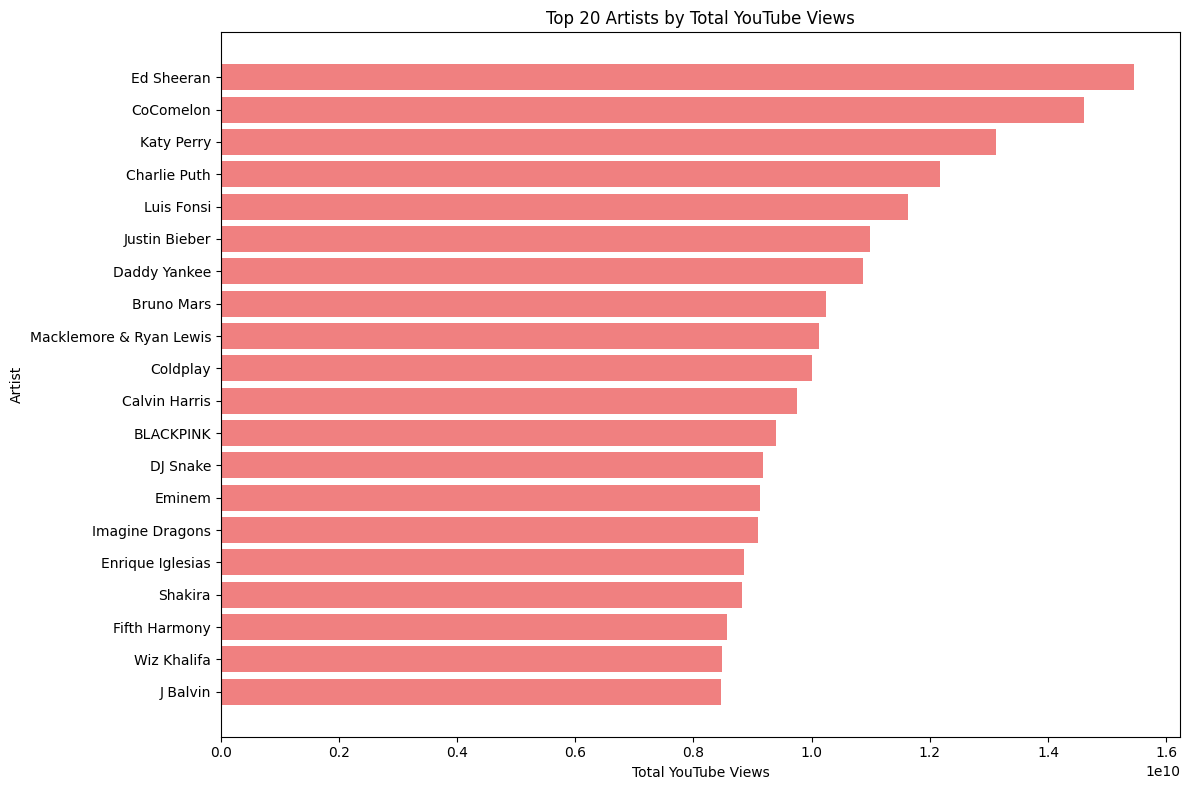

In [ ]:
### Below is the original AI output from Gemini in Google Colab

# Prompt: create a new data frame counting the total number of streams of each unique singer's songs from ds1
artist_streams = ds1.groupby('Artist')['Stream'].sum().reset_index()
artist_streams = artist_streams.rename(columns={'Stream': 'Total Streams'})
display(artist_streams.head())

# Prompt: create a new data frame counting the total number of streams of each unique singer's YouTube Mvs from ds1
artist_youtube_views = ds1.groupby('Artist')['Views'].sum().reset_index()
artist_youtube_views = artist_youtube_views.rename(columns={'Views': 'Total YouTube Views'})
display(artist_youtube_views.head())

# Prompt: plot the data frames into bar charts
# Sort the artists by total streams in descending order and take the top 20
top_artists_streams = artist_streams.sort_values(by='Total Streams', ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.barh(top_artists_streams['Artist'], top_artists_streams['Total Streams'], color='skyblue')
plt.xlabel('Total Streams')
plt.ylabel('Artist')
plt.title('Top 20 Artists by Total Streams on Spotify')
plt.gca().invert_yaxis() # Invert y-axis to have the highest stream artist at the top
plt.tight_layout()
plt.show()

# Sort the artists by total YouTube Views in descending order and take the top 20
top_artists_youtube = artist_youtube_views.sort_values(by='Total YouTube Views', ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.barh(top_artists_youtube['Artist'], top_artists_youtube['Total YouTube Views'], color='lightcoral')
plt.xlabel('Total YouTube Views')
plt.ylabel('Artist')
plt.title('Top 20 Artists by Total YouTube Views')
plt.gca().invert_yaxis() # Invert y-axis to have the highest view artist at the top
plt.tight_layout()
plt.show()


The charts generated above demonstrate singnificant differences in the total number of streams of each Spotify artist's top 10 songs. An explanation for such a phenomenon could be the difference in the total number of fans of each artist. Therefore, to avoid potential bias from differing fanbase sizes, we will only be comparing songs within each individual artist.

 **Data Quality Considerations**

Our group considers this dataset to be suitable for the following factors:

- **Comprehensiveness**: This dataset covers a wide range of singer/artists of different genres of music

- **Usability**: The attributes of each song are clearly stated with numerical values to be analyzed

- **Reputation**: This dataset found on Kaggle recieved high votes and many other users find it very useful

**Data Conclusion**

From our perspecitve, this dataset enables us to explore how musical attributes influence listener engagement on Spotify and YouTube, as well as cross-platform popularity patterns. With proper cleaning and normalization, it can support predictive modeling of song success, contributing to our topic.

### **DS2: 30000 Spotify Songs**

**Description**

 The dataset contains information on approximately 30,000 most-played songs collected from Spotify, comprising track metadata, audio features, and popularity indicators. It integrates musical characteristics with platform-level engagement metrics, enabling analysis of how song attributes relate to popularity and genre classification.



In [ ]:
# Read the ds2 .csv file
ds2 = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv')
display(ds2)

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,42,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,20,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,14,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,15,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432


**Exploring Genres**

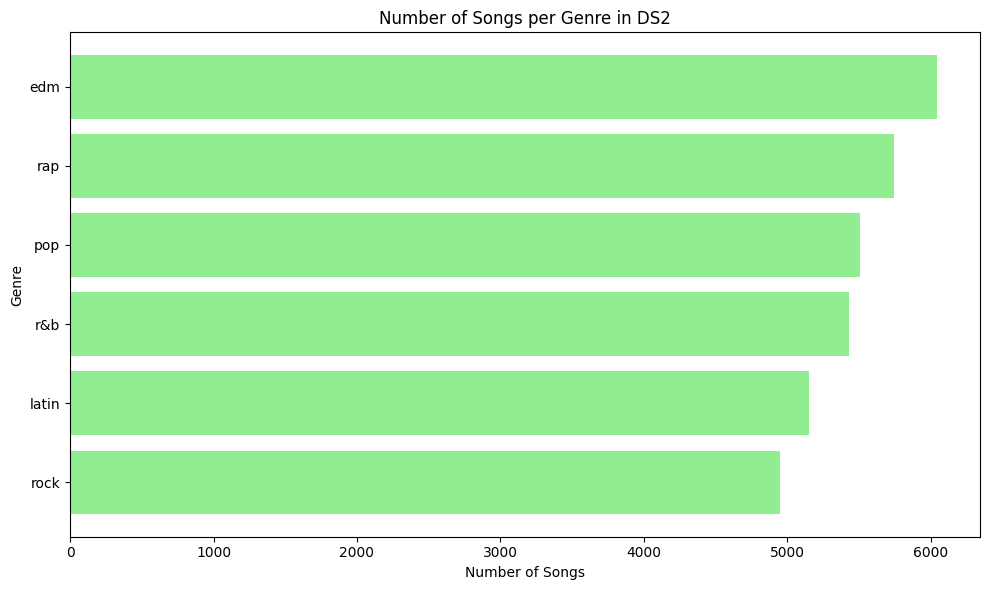

In [ ]:
### Below are the original output of Gemini in Google Colab

# Prompt: Count the number of songs in each genre in ds2 and plot a bar chart
# Count the number of songs in each genre
genre_counts = ds2['playlist_genre'].value_counts().reset_index()
genre_counts.columns = ['Genre', 'Count']

# Plot a bar chart
plt.figure(figsize=(10, 6))
plt.barh(genre_counts['Genre'], genre_counts['Count'], color='lightgreen')
plt.xlabel('Number of Songs')
plt.ylabel('Genre')
plt.title('Number of Songs per Genre in DS2')
plt.gca().invert_yaxis() # Invert y-axis to have the highest count at the top
plt.tight_layout()
plt.show()


According to data exploration, we observe that there is a wide range of genres covered in the dataset with "edm" in the lead, which has approximately 6000 songs. This introduces potential bias, since "edm" may dominate popular songs solely due to its large sample size, misleading us to overlook other audio features presented in genres with smaller sample sizes.

**Exploring Time Range**

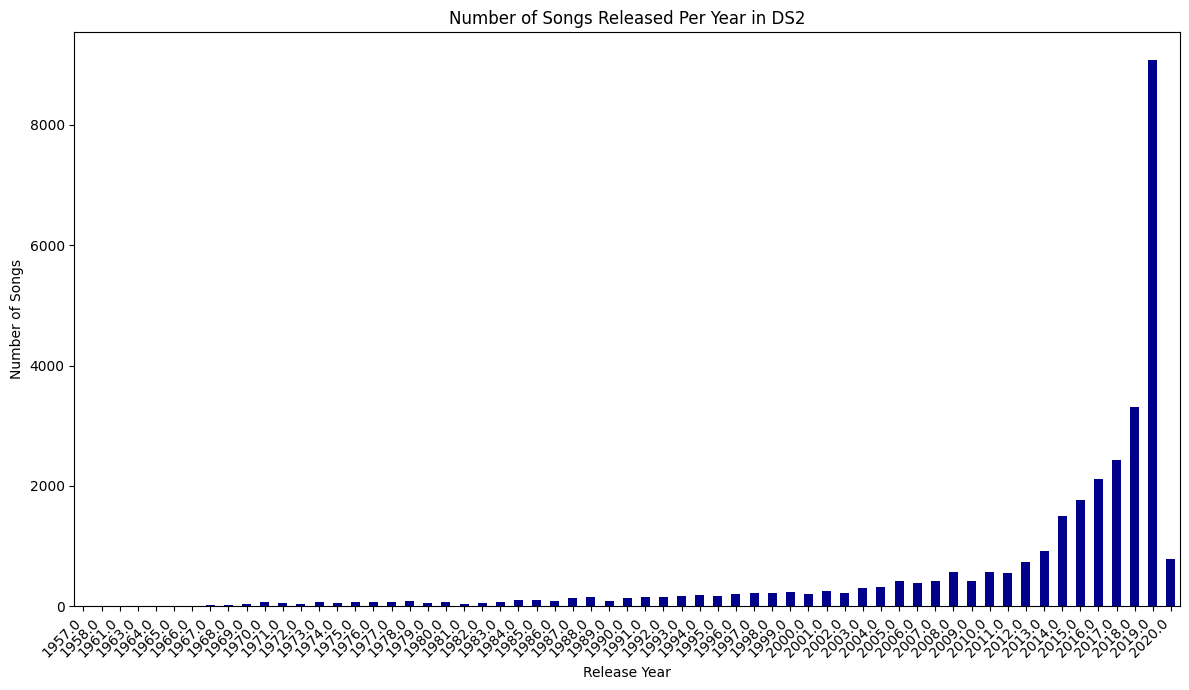

In [ ]:
### Below is the original output from Gemini in Google Colab

# Prompt: Count the number of songs in released in each year in ds2 and plot a bar chart

# Convert 'track_album_release_date' to datetime objects and extract the year
ds2['release_year'] = pd.to_datetime(ds2['track_album_release_date'], errors='coerce').dt.year

# Count the number of songs per year
year_counts = ds2['release_year'].value_counts().sort_index()

# Plot a bar chart
plt.figure(figsize=(12, 7))
year_counts.plot(kind='bar', color='darkblue')
plt.xlabel('Release Year')
plt.ylabel('Number of Songs')
plt.title('Number of Songs Released Per Year in DS2')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Exploring the release date proves to be crucial as people's music tastes change overtime. The bar chart illustrates that a multitude of songs were released from 2010 to 2020, peaking in 2019. Although this data recounts to a few years ago, it is still relatively accountable.

**Data Quality Considerations**

- **Large Sample Size**: With almost 30k songs included, it ensures ample data for this study.

- **Genre and Subgenre Labels**: Besides audio characteristics given by Spotify, this dataset also takes music genre into account, providing us with another factor that enriches the data, which could lead to a more comprehensive analysis.



**Data Conclusion**

 This dataset provides a comprehensive basis for exploring patterns in contemporary music on Spotify, particularly the relationship between audio features, genre classification, and song popularity. With proper preprocessing and normalization, it is well suited for the predictive modeling of popularity on Spotify, enable later comparison with the popularity on YouTube to find key characteristics for a cross-platform hit.

### **DS3: YouTube Top 100 Songs 2025 Dataset**

**Description**

This dataset captures the YouTube Top 100 Songs in 2025. Featuring comprehensive metadata for the year’s most popular tracks, including view counts, tags, categories etc.

In [ ]:
# Read the .csv file
ds3 = pd.read_csv('/content/drive/MyDrive/SC3021 datasets/youtube-top-100-songs-2025.csv')

display(ds3)

,title,fulltitle,description,view_count,categories,tags,duration,duration_string,live_status,thumbnail,channel,channel_url,channel_follower_count
0,ROSÉ & Bruno Mars - APT. (Official Music Video),ROSÉ & Bruno Mars - APT. (Official Music Video),ROSÉ & Bruno Mars - APT.\nDownload/stream: ht...,2009014557,Music,YG Entertainment;YG;와이지;K-pop;BLACKPINK;블랙핑크;블...,173,2:53,False,https://i.ytimg.com/vi_webp/ekr2nIex040/maxres...,ROSÉ,https://www.youtube.com/channel/UCBo1hnzxV9rz3...,19200000
1,"Lady Gaga, Bruno Mars - Die With A Smile (Offi...","Lady Gaga, Bruno Mars - Die With A Smile (Offi...",MAYHEM OUT NOW\nhttp://ladygaga.com \n \nListe...,1324833300,Music,Lady Gaga;Bruno Mars;Interscope;Pop,252,4:12,False,https://i.ytimg.com/vi/kPa7bsKwL-c/maxresdefau...,Lady Gaga,https://www.youtube.com/channel/UC07Kxew-cMIay...,29600000
2,Reneé Rapp - Leave Me Alone (Official Music Vi...,Reneé Rapp - Leave Me Alone (Official Music Vi...,"Listen to “BITE ME”, the new album from Reneé ...",2536628,Music,Reneé Rapp;Interscope Records;Pop,160,2:40,False,https://i.ytimg.com/vi/tiPWzFLiz4A/maxresdefau...,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000
3,Billie Eilish - BIRDS OF A FEATHER (Official M...,Billie Eilish - BIRDS OF A FEATHER (Official M...,Listen to HIT ME HARD AND SOFT: https://billie...,558329099,Music,Billie Eilish;Darkroom/Interscope Records;Alte...,231,3:51,False,https://i.ytimg.com/vi/V9PVRfjEBTI/maxresdefau...,Billie Eilish,https://www.youtube.com/channel/UCDGmojLIoWpXo...,56800000
4,Reneé Rapp - Mad (Official Music Video),Reneé Rapp - Mad (Official Music Video),"Listen to “BITE ME”, the new album from Reneé ...",2113548,Music,Reneé Rapp;Interscope Records;Pop,180,3:00,False,https://i.ytimg.com/vi/xkWQM3flsiY/maxresdefau...,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Ariana Grande - twilight zone (Official Lyric ...,Ariana Grande - twilight zone (Official Lyric ...,The official “twilight zone” official lyric vi...,18245315,Music,Ariana Grande;Republic Records;Pop,202,3:22,False,https://i.ytimg.com/vi/x1XIJM6spaE/maxresdefau...,Ariana Grande,https://www.youtube.com/channel/UC0VOyT2OCBKdQ...,56400000
96,"Gracie Abrams - I Love You, I’m Sorry (Officia...","Gracie Abrams - I Love You, I’m Sorry (Officia...","Listen to the new album, The Secret of Us, out...",31456772,Music,"Gracie Abrams;Gracie Abrams, under exclusive l...",234,3:54,False,https://i.ytimg.com/vi/uxjhN_Donfw/maxresdefau...,Gracie Abrams,https://www.youtube.com/channel/UCVFRVXH1hRoWk...,1770000
97,HoodTrophy Bino ft. FCG Heem - Miami (Official...,HoodTrophy Bino ft. FCG Heem - Miami (Official...,HoodTrophy Bino and FCG Heem drop Miami. From...,66051,Music,NaN,197,3:17,False,https://i.ytimg.com/vi_webp/I-gmbHgeN1I/maxres...,HoodTrophy Bino,https://www.youtube.com/channel/UCsaZi3QZrZ5-s...,20300
98,Sean Paul x INNA - Let It Talk To Me,Sean Paul x INNA - Let It Talk To Me,Song Title: Sean Paul x INNA - Let It Talk To ...,16952860,Music,Sean Paul,155,2:35,False,https://i.ytimg.com/vi_webp/nkRyAVQdqAA/maxres...,Sean Paul,https://www.youtube.com/channel/UCkdc7gHpavxpg...,5200000


**Exploring View Distribution**

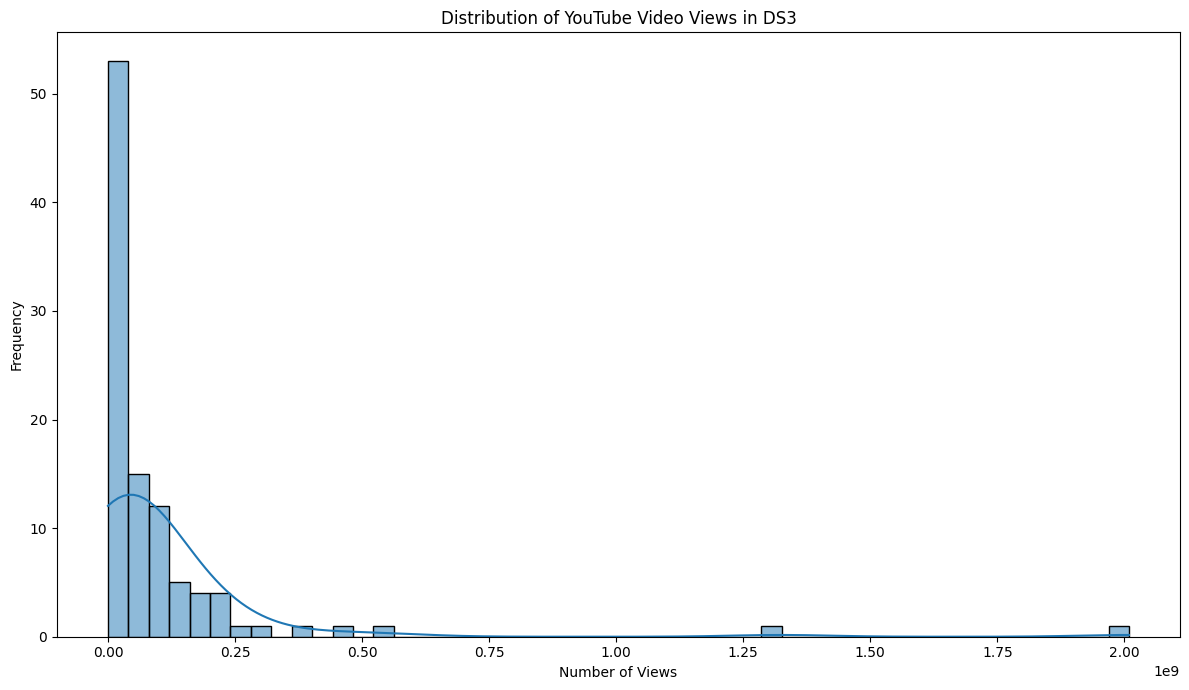

In [ ]:
### Below is the original outout from Gemini in Google Colab

# Prompt: Plot a chart on the distribution of number of views of Youtube videos in ds3

plt.figure(figsize=(12,7))

sns.histplot(ds3['view_count'], bins=50, kde=True)

plt.xlabel('Number of Views')
plt.ylabel('Frequency')
plt.title('Distribution of YouTube Video Views in DS3')

plt.tight_layout()
plt.show()

From the distribution we can see that most of the songs have their view counts around 100~200 million, indicating the dataset is indeed featuring top songs instead of random music video uploads.

**Data Quality Considerations**

- **Managable Size**: Compared to DS1 and DS2 with huge numbers of rows, this data set only contains the most popular songs on Youtube in 2025 making the analysis process simplier.

- **Temporality**: This dataset was collected in 2025, enabling a more accurate analysis for songs recently.

- **Platform Specific**: The dataset solely focuses on YouTube MVs. Despite "number of views" being the only numerical attribute provided, by data enriching and linking DS2 and DS3 dynamically, we are able to complete the neccessary audio characteristics for analysis.


**Data Conclusion**

Overall, the YouTube Top Songs 2020-2023 dataset offers a concise yet powerful view of contemporary music popularity on YouTube. Its strong focus on high-impact songs and clear engagement indicators makes it well suited for our topic of trend analysis of hit songs and music.

### **DS4: Spotify Most Streamed Songs (Not Used)**

**Description**

The dataset focuses on the most streamed songs on Spotify, emphasizing song popularity by showing the songs streams and occurence in Spotify and Apple Music playlists.

In [ ]:
# Read the .csv file
ds4 = pd.read_csv('/content/drive/MyDrive/SC3021 datasets/Spotify Most Streamed Songs.csv')

display(ds4)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,B,Major,80,89,83,31,0,8,4,Not Found
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,C#,Major,71,61,74,7,0,10,4,https://i.scdn.co/image/ab67616d0000b2730656d5...
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,F,Major,51,32,53,17,0,31,6,https://i.scdn.co/image/ab67616d0000b273e85259...
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,A,Major,55,58,72,11,0,11,15,https://i.scdn.co/image/ab67616d0000b273e787cf...
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,A,Minor,65,23,80,14,63,11,6,https://i.scdn.co/image/ab67616d0000b273ab5c9c...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,My Mind & Me,Selena Gomez,1,2022,11,3,953,0,91473363,61,...,A,Major,60,24,39,57,0,8,3,https://i.scdn.co/image/ab67616d0000b2730f5397...
949,Bigger Than The Whole Sky,Taylor Swift,1,2022,10,21,1180,0,121871870,4,...,F#,Major,42,7,24,83,1,12,6,https://i.scdn.co/image/ab67616d0000b273e0b60c...
950,A Veces (feat. Feid),"Feid, Paulo Londra",2,2022,11,3,573,0,73513683,2,...,C#,Major,80,81,67,4,0,8,6,Not Found
951,En La De Ella,"Feid, Sech, Jhayco",3,2022,10,20,1320,0,133895612,29,...,C#,Major,82,67,77,8,0,12,5,Not Found


**Exploring the Number of Artists Involved**

In [ ]:
# Find the number of unque involved
unique_artists2 = ds4['artist(s)_name'].unique()
print(f'List of unique artists:\n{unique_artists}')
print(f'\nThe number of unique artists is: {len(unique_artists)}')

List of unique artists:
['Gorillaz' 'Red Hot Chili Peppers' '50 Cent' ... 'LE SSERAFIM' 'ThxSoMch'
 'SICK LEGEND']

The number of unique artists is: 2079


Despite including a wide range of artists, the number of songs of each artist is relatively low compared to that of DS1, making comparison within each individual artist difficult due to small sample size.

**Data Quality Considerations**

- **Incomplete Values**: Large quantity of missing values increases difficulty during the analysis stage.

- **Relative size of the data**: This dataset has the same data types and attributes as DS1, only with a much smaller sample size.


**Data Conclusion**

As these datasets were all collected via the Spotify API and contain almost identical types of information, we will place greater emphasis on dataset size when selecting them, as larger datasets contain more data and facilitate a more comprehensive analysis. DS4 is basically a small slice of the songs in DS1 with even fewer information, missing the row "YouTube Views". So we decided to discard this dataset as DS1 covers it completely.

## **3. Data Preparation (Process)**

**Brief Overview**

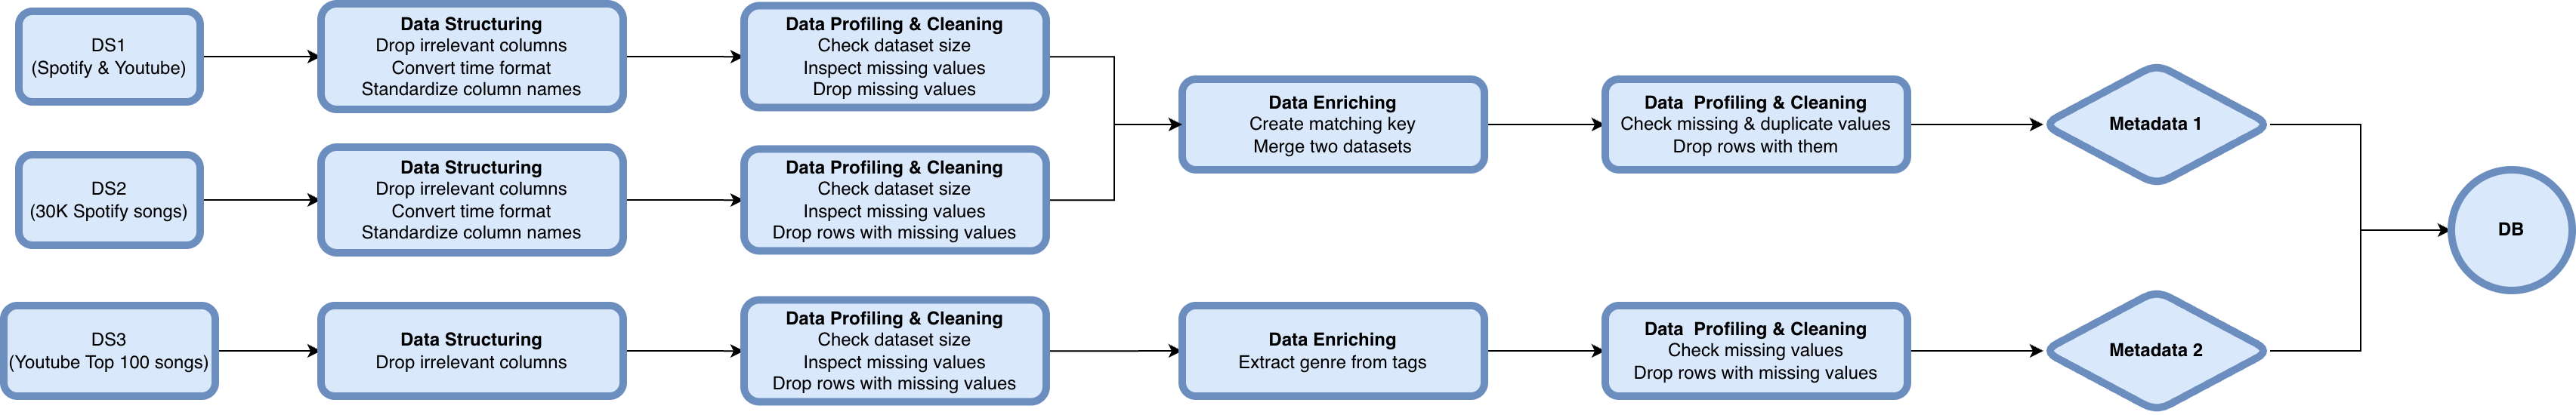

### **A. Data Structuring**

**1. Remove Irrelevant Columns**

We'll remove some columns in DS1, DS2 and DS3 as they include irrelevant information that do not help on the analysis.

In [ ]:
# Drop Irrelevant columns
spotifyAndYoutube = ds1.drop(columns = ["Url_spotify", "Album", "Album_type", "Uri", "Url_youtube", "Title", "Channel", "Description", "Licensed", "official_video"])
spotifySongs = ds2.drop(columns = ["track_id", "track_album_id","track_album_name", "track_album_release_date", "playlist_name", "playlist_id", "mode", "track_popularity"])
youtubeTopSongs2025 = ds3.drop(columns = ["fulltitle", "categories", "description", "duration_string", "live_status", "thumbnail"])


**2. Data Conversion**

We'll convert the duration of the song from millisecond to second in DS1 and DS2 to allow a more intuitive analysis.

In [ ]:
# A second equals 1000ms
def millisecToSec(ms):
  sec = ms / 1000
  return sec

# Convert ms in each dataset to s
spotifyAndYoutube["Duration_ms"] = spotifyAndYoutube["Duration_ms"].apply(millisecToSec)
spotifySongs["duration_ms"] = spotifySongs["duration_ms"].apply(millisecToSec)

# Rename the column
spotifyAndYoutube = spotifyAndYoutube.rename(columns = {"Duration_ms": "Duration"})
spotifySongs = spotifySongs.rename(columns = {"duration_ms": "Duration"})

**3. Standardize Column Names**

DS1 and DS2, being different datasets, have different column names. Therefore, for the merge of data later, we have to unify column names in both datasets here.


In [ ]:
# Make column names to lowercase letters
spotifyAndYoutube.columns = spotifyAndYoutube.columns.str.lower()
spotifySongs.columns = spotifySongs.columns.str.lower()
youtubeTopSongs2025.columns = youtubeTopSongs2025.columns.str.lower()

# Rename columns in DS2
spotifySongs = spotifySongs.rename(columns = {"track_name": "track", "track_artist": "artist"})


### **B. Data Profiling**

**1. Check Dataset Sizes**

We start by examining the shape and columns of each dataset to understand how many songs are available.

In [ ]:
print(spotifyAndYoutube.shape)
print(spotifySongs.shape)
print(youtubeTopSongs2025.shape)

(20718, 18)
(32833, 16)
(100, 7)


**2. Inspect Missing Values**

We quantify missing values in each dataset to identify incomplete data. Understanding the proportion of nulls helps us decide how to handle them.

In [ ]:
nullPercentDs1 = spotifyAndYoutube.isnull().sum() / len(spotifyAndYoutube) * 100
nullPercentDs2 = spotifySongs.isnull().sum() / len(spotifySongs) * 100
nullPercentDs3 = youtubeTopSongs2025.isnull().sum() / len(youtubeTopSongs2025) * 100

print("DS1 null %:\n", nullPercentDs1)
print("DS2 null %:\n", nullPercentDs2)
print("DS3 null %:\n", nullPercentDs3)

DS1 null %:
 unnamed: 0          0.000000
artist              0.000000
track               0.000000
danceability        0.009653
energy              0.009653
key                 0.009653
loudness            0.009653
speechiness         0.009653
acousticness        0.009653
instrumentalness    0.009653
liveness            0.009653
valence             0.009653
tempo               0.009653
duration            0.009653
views               2.268559
likes               2.611256
comments            2.746404
stream              2.780191
dtype: float64
DS2 null %:
 track                0.015229
artist               0.015229
playlist_genre       0.000000
playlist_subgenre    0.000000
danceability         0.000000
energy               0.000000
key                  0.000000
loudness             0.000000
speechiness          0.000000
acousticness         0.000000
instrumentalness     0.000000
liveness             0.000000
valence              0.000000
tempo                0.000000
duration         

- In DS1 and DS2, we can see that there's only few missing values that account for a small proportion of the dataset, so we'll simply perform data cleaning by dropping the null values.

- In DS3, due to the relatively small dataset size, simply dropping null rows is not the best option. So we decided to add rows with missing tags manually by searching them in youtube.

### **C. Data Cleaning**

**1. Clean The Key Fields**

By removing case, spacing issues and possible duplicates, this step helps avoid potential problems which may arise later when we create a new key for identifying songs using names.

Also, cleaning the track name is important as many songs contain unneccessary information like:
- (feat....)
- remastered
- live
- remix
etc.

By dropping these extra information we can more clearly identify a unique song.

In [ ]:
# Unify case and remove potential spacings
for df in [spotifyAndYoutube, spotifySongs]:
  df["track"] = df["track"].astype(str).str.lower().str.strip()
  df["artist"] = df["artist"].astype(str).str.lower().str.strip()
  df = df.drop_duplicates()


# Cleaning unecessary information
def cleanTitle(title):
  title = re.sub(r"\(.*\)", "", title) # Remove (feat...) etc.
  title = re.sub(r"-.*", "", title) # Remove -Remastered, -live, -remix etc.
  return title.strip() # Retrun the cleaned title

 # Not youtubeTopSongs this time as in this dataset artists & song names are connected by "-"
for df in [spotifyAndYoutube, spotifySongs]:
  df["track"] = df["track"].apply(cleanTitle)

**2. Dealing with Null Values**

In this step we'll do the following 2 things:

- Drop rows with null values in DS1 and DS2
- Extract the rows in DS3 with empty tags and see if we can enrich them manually.

In [ ]:
# Drop empty rows in DS1 & DS2
spotifyAndYoutube = spotifyAndYoutube.dropna()
spotifySongs = spotifySongs.dropna()


# Extract empty rows from DS3
emptyTags = youtubeTopSongs2025[youtubeTopSongs2025['tags'].isnull()]
display(emptyTags)

,title,view_count,tags,duration,channel,channel_url,channel_follower_count
10,Zillionaire Doe - How It's Going (Official Video),1198540,NaN,152,Zillionaire Doe,https://www.youtube.com/channel/UCbVdo2e1hDYR9...,142000
11,Alex Warren - Ordinary (Official Video),147871443,NaN,187,Alex Warren,https://www.youtube.com/channel/UCX2Pm1JoWF3ch...,4050000
12,Kendrick Lamar - luther (Official Audio),142084039,NaN,178,Kendrick Lamar,https://www.youtube.com/channel/UC3lBXcrKFnFAF...,19700000
22,Tommy Richman - MILLION DOLLAR BABY (Official ...,45822601,NaN,156,Tommy Richman,https://www.youtube.com/channel/UC7eumlwt8zpmN...,655000
25,"Adam Port, Stryv - Move feat. Malachiii (Exten...",87005996,NaN,353,keinemusik,https://www.youtube.com/channel/UCYzx8QoAiRb69...,255000
26,Tutipsy & Niickii - Afro Disco (Visualizer),17322,NaN,154,NIICKII,https://www.youtube.com/channel/UChcyluLsfj0ge...,47
31,NIGHT SKIES (Official Music Video),6605,NaN,137,Chxnny,https://www.youtube.com/channel/UCcA274LONuELr...,3630
32,SEVDALIZA - ALIBI FT. PABLLO VITTAR & YSEULT (...,236500879,NaN,193,Sevdaliza,https://www.youtube.com/channel/UCONnf7g7QfOqz...,1230000
35,squabble up,70965585,NaN,166,Kendrick Lamar,https://www.youtube.com/channel/UC3lBXcrKFnFAF...,19700000
44,David Guetta & Sia - Beautiful People (Officia...,41075369,NaN,204,David Guetta,https://www.youtube.com/channel/UC1l7wYrva1qCH...,27600000


Upon verifying the songs with missing tags on YouTube, we confirmed that these videos were never tagged by their uploaders. Since the tags do not exist at the source, the missing values cannot be filled in, thus we will drop these rows from the dataset.

In [ ]:
youtubeTopSongs2025 = youtubeTopSongs2025.dropna()

### **D. Data Enriching**

**1. Create a Match Key**

Since the dataset contains many songs of the same artists and there might be songs from different artists with the same name, here our match key will be "artist + track name", as they usually can uniquely identify a song. Since song names in DS3 are already in the format of match key, there's no need to apply the method to DS3.

In [ ]:
# Merge Key: track + artist
for df in [spotifyAndYoutube, spotifySongs]:
  spotifyAndYoutube['match_key'] = spotifyAndYoutube['artist'] + ' - ' + spotifyAndYoutube['track']
  spotifySongs['match_key'] = spotifySongs['artist'] + ' - ' + spotifySongs['track']

In [ ]:
display(spotifySongs)

,track,artist,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration,release_year,match_key
0,i don't care,ed sheeran,pop,dance pop,0.748,0.916,6,-2.634,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194.754,2019.0,ed sheeran - i don't care
1,memories,maroon 5,pop,dance pop,0.726,0.815,11,-4.969,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162.600,2019.0,maroon 5 - memories
2,all the time,zara larsson,pop,dance pop,0.675,0.931,1,-3.432,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176.616,2019.0,zara larsson - all the time
3,call you mine,the chainsmokers,pop,dance pop,0.718,0.930,7,-3.778,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169.093,2019.0,the chainsmokers - call you mine
4,someone you loved,lewis capaldi,pop,dance pop,0.650,0.833,1,-4.672,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189.052,2019.0,lewis capaldi - someone you loved
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,city of lights,lush & simon,edm,progressive electro house,0.428,0.922,2,-1.814,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204.375,2014.0,lush & simon - city of lights
32829,closer,tegan and sara,edm,progressive electro house,0.522,0.786,0,-4.462,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353.120,2013.0,tegan and sara - closer
32830,sweet surrender,starkillers,edm,progressive electro house,0.529,0.821,6,-4.899,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210.112,2014.0,starkillers - sweet surrender
32831,only for you,mat zo,edm,progressive electro house,0.626,0.888,2,-3.361,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367.432,2014.0,mat zo - only for you


**2. Add new attributes**

For the analysis of song genres, we will proceed with the following 2 steps:
- Based on the match_key, merge the rows with attribute "playlist_genre" in DS2 with songs in DS1 to add the genre attribute to DS1 songs, i.e. perform an inner join

- Extract genre of songs in DS3 from the column "tags" to allow analysis on music genres

In [ ]:
# Merge the 2 datasets on match_key
spotifyAndYoutubeMerged = spotifyAndYoutube.merge(spotifySongs[['match_key', 'playlist_genre']], on='match_key', how='left')
display(spotifyAndYoutubeMerged)

# Extract the genre from tags in DS3

# Common music tags that could appear
genres = [
    'pop', 'dance pop', 'teen pop', 'synth-pop', 'k-pop', 'j-pop',
    'rock', 'classic rock', 'indie rock', 'alternative rock', 'punk rock', 'hard rock', 'metal', 'grunge', 'emo',
    'hip hop', 'rap', 'trap', 'lo-fi hip hop', 'conscious rap', 'gangsta rap',
    'edm', 'house', 'techno', 'trance', 'dubstep', 'drum and bass', 'chillout', 'future bass', 'synthwave',
    'r&b', 'neo soul', 'soul', 'funk', 'motown',
    'jazz', 'smooth jazz', 'bebop', 'blues', 'blues rock', 'swing',
    'country', 'country pop', 'bluegrass', 'folk', 'indie folk', 'americana',
    'classical', 'baroque', 'romantic', 'contemporary classical', 'soundtrack', 'instrumental',
    'reggae', 'dancehall', 'afrobeat', 'latin', 'salsa', 'tango', 'flamenco',
    'punk', 'metalcore', 'emo', 'lo-fi', 'experimental', 'ambient', 'chillwave', 'vaporwave'
]

def extractGenre(tags):
  tags = str(tags)
  tags = tags.strip().lower()
  tagList = tags.split(";")

  genreList = [t for t in tagList if t in genres]
  # Keep the tags that match the genre
  tagList = [t for t in tagList if t in genres]
  return ",".join(tagList)

youtubeTopSongs2025['genres'] = youtubeTopSongs2025['tags'].apply(extractGenre)

display(youtubeTopSongs2025)


,unnamed: 0,artist,track,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration,views,likes,comments,stream,match_key,playlist_genre
0,0,gorillaz,feel good inc.,0.818,0.705,6.0,-6.679,0.1770,0.008360,0.002330,0.6130,0.7720,138.559,222.640,693555221.0,6220896.0,169907.0,1.040235e+09,gorillaz - feel good inc.,rock
1,0,gorillaz,feel good inc.,0.818,0.705,6.0,-6.679,0.1770,0.008360,0.002330,0.6130,0.7720,138.559,222.640,693555221.0,6220896.0,169907.0,1.040235e+09,gorillaz - feel good inc.,rock
2,1,gorillaz,rhinestone eyes,0.676,0.703,8.0,-5.815,0.0302,0.086900,0.000687,0.0463,0.8520,92.761,200.173,72011645.0,1079128.0,31003.0,3.100837e+08,gorillaz - rhinestone eyes,NaN
3,2,gorillaz,new gold,0.695,0.923,1.0,-3.930,0.0522,0.042500,0.046900,0.1160,0.5510,108.014,215.150,8435055.0,282142.0,7399.0,6.306347e+07,gorillaz - new gold,NaN
4,3,gorillaz,on melancholy hill,0.689,0.739,2.0,-5.810,0.0260,0.000015,0.509000,0.0640,0.5780,120.423,233.867,211754952.0,1788577.0,55229.0,4.346636e+08,gorillaz - on melancholy hill,pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22839,20713,sick legend,just dance hardstyle,0.582,0.926,5.0,-6.344,0.0328,0.448000,0.000000,0.0839,0.6580,90.002,94.667,71678.0,1113.0,0.0,9.227144e+06,sick legend - just dance hardstyle,NaN
22840,20714,sick legend,set fire to the rain hardstyle,0.531,0.936,4.0,-1.786,0.1370,0.028000,0.000000,0.0923,0.6570,174.869,150.857,164741.0,2019.0,0.0,1.089818e+07,sick legend - set fire to the rain hardstyle,NaN
22841,20715,sick legend,outside hardstyle sped up,0.443,0.830,4.0,-4.679,0.0647,0.024300,0.000000,0.1540,0.4190,168.388,136.842,35646.0,329.0,0.0,6.226110e+06,sick legend - outside hardstyle sped up,NaN
22842,20716,sick legend,only girl hardstyle,0.417,0.767,9.0,-4.004,0.4190,0.356000,0.018400,0.1080,0.5390,155.378,108.387,6533.0,88.0,0.0,6.873961e+06,sick legend - only girl hardstyle,NaN


,title,view_count,tags,duration,channel,channel_url,channel_follower_count,genres
0,ROSÉ & Bruno Mars - APT. (Official Music Video),2009014557,YG Entertainment;YG;와이지;K-pop;BLACKPINK;블랙핑크;블...,173,ROSÉ,https://www.youtube.com/channel/UCBo1hnzxV9rz3...,19200000,k-pop
1,"Lady Gaga, Bruno Mars - Die With A Smile (Offi...",1324833300,Lady Gaga;Bruno Mars;Interscope;Pop,252,Lady Gaga,https://www.youtube.com/channel/UC07Kxew-cMIay...,29600000,pop
2,Reneé Rapp - Leave Me Alone (Official Music Vi...,2536628,Reneé Rapp;Interscope Records;Pop,160,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000,pop
3,Billie Eilish - BIRDS OF A FEATHER (Official M...,558329099,Billie Eilish;Darkroom/Interscope Records;Alte...,231,Billie Eilish,https://www.youtube.com/channel/UCDGmojLIoWpXo...,56800000,
4,Reneé Rapp - Mad (Official Music Video),2113548,Reneé Rapp;Interscope Records;Pop,180,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000,pop
...,...,...,...,...,...,...,...,...
94,Justin Bieber - YUKON,21968615,justin;bieber;justinbieber;purpose;myworld;jou...,183,Justin Bieber,https://www.youtube.com/channel/UCIwFjwMjI0y7P...,76200000,"r&b,pop"
95,Ariana Grande - twilight zone (Official Lyric ...,18245315,Ariana Grande;Republic Records;Pop,202,Ariana Grande,https://www.youtube.com/channel/UC0VOyT2OCBKdQ...,56400000,pop
96,"Gracie Abrams - I Love You, I’m Sorry (Officia...",31456772,"Gracie Abrams;Gracie Abrams, under exclusive l...",234,Gracie Abrams,https://www.youtube.com/channel/UCVFRVXH1hRoWk...,1770000,pop
98,Sean Paul x INNA - Let It Talk To Me,16952860,Sean Paul,155,Sean Paul,https://www.youtube.com/channel/UCkdc7gHpavxpg...,5200000,


**3. Profiling and Drop Null rows**

We count the number of null and duplicate values in a dataset and remove the affected rows to ensure the data is clean before analysis.

In [ ]:
# Count the number of nulls
spotifyAndYoutubeNullCount = spotifyAndYoutubeMerged.isnull().sum()
youtubeTopSongs2025NullCount = youtubeTopSongs2025.isnull().sum()

print("DS1 null count:\n", spotifyAndYoutubeNullCount)
print("DS3 null count:\n", youtubeTopSongs2025NullCount)
print("\n")

# Count the number of duplicates that may result from the merge
spotifyAndYoutubeDubCount = spotifyAndYoutubeMerged.duplicated().sum()

print("DS1 duplicate count:\n", spotifyAndYoutubeDubCount)

# Drop the rows with null and duplicate values
spotifyAndYoutubeMerged = spotifyAndYoutubeMerged.dropna()
spotifyAndYoutubeMerged = spotifyAndYoutubeMerged.drop_duplicates() # Final Dataset1

# Replace empty strings with NaN then drop
youtubeTopSongs2025['genres'] = youtubeTopSongs2025['genres'].replace('', np.nan)
youtubeTopSongs2025 = youtubeTopSongs2025.dropna(subset=['genres']) # Final Datset2

print(spotifyAndYoutubeMerged.shape)
print(youtubeTopSongs2025.shape)

display(spotifyAndYoutubeMerged)
display(youtubeTopSongs2025)

DS1 null count:
 unnamed: 0              0
artist                  0
track                   0
danceability            0
energy                  0
key                     0
loudness                0
speechiness             0
acousticness            0
instrumentalness        0
liveness                0
valence                 0
tempo                   0
duration                0
views                   0
likes                   0
comments                0
stream                  0
match_key               0
playlist_genre      16679
dtype: int64
DS3 null count:
 title                     0
view_count                0
tags                      0
duration                  0
channel                   0
channel_url               0
channel_follower_count    0
genres                    0
dtype: int64


DS1 duplicate count:
 2185
(3980, 20)
(41, 8)


,unnamed: 0,artist,track,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration,views,likes,comments,stream,match_key,playlist_genre
0,0,gorillaz,feel good inc.,0.818,0.705,6.0,-6.679,0.1770,0.008360,0.002330,0.613,0.772,138.559,222.640,6.935552e+08,6220896.0,169907.0,1.040235e+09,gorillaz - feel good inc.,rock
4,3,gorillaz,on melancholy hill,0.689,0.739,2.0,-5.810,0.0260,0.000015,0.509000,0.064,0.578,120.423,233.867,2.117550e+08,1788577.0,55229.0,4.346636e+08,gorillaz - on melancholy hill,pop
10,9,gorillaz,dirty harry,0.625,0.877,10.0,-7.176,0.1620,0.031500,0.081100,0.672,0.865,192.296,230.426,1.547611e+08,1386920.0,39240.0,1.910747e+08,gorillaz - dirty harry,rock
11,10,red hot chili peppers,californication,0.592,0.767,9.0,-2.788,0.0270,0.002100,0.001650,0.127,0.328,96.483,329.733,1.018811e+09,4394471.0,121452.0,1.055738e+09,red hot chili peppers - californication,rock
13,11,red hot chili peppers,under the bridge,0.559,0.345,4.0,-13.496,0.0459,0.057600,0.000105,0.141,0.458,84.581,264.307,2.466877e+08,1213572.0,32761.0,1.061751e+09,red hot chili peppers - under the bridge,rock
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22506,20346,meduza,piece of your heart,0.677,0.744,10.0,-6.806,0.0295,0.040400,0.000160,0.074,0.631,124.080,152.913,8.590940e+07,691091.0,5218.0,8.742311e+08,meduza - piece of your heart,edm
22512,20348,meduza,piece of your heart,0.797,0.860,10.0,-4.380,0.0413,0.031200,0.013700,0.334,0.192,124.033,166.452,4.345021e+07,540052.0,8847.0,2.821638e+08,meduza - piece of your heart,pop
22513,20348,meduza,piece of your heart,0.797,0.860,10.0,-4.380,0.0413,0.031200,0.013700,0.334,0.192,124.033,166.452,4.345021e+07,540052.0,8847.0,2.821638e+08,meduza - piece of your heart,latin
22515,20348,meduza,piece of your heart,0.797,0.860,10.0,-4.380,0.0413,0.031200,0.013700,0.334,0.192,124.033,166.452,4.345021e+07,540052.0,8847.0,2.821638e+08,meduza - piece of your heart,r&b


,title,view_count,tags,duration,channel,channel_url,channel_follower_count,genres
0,ROSÉ & Bruno Mars - APT. (Official Music Video),2009014557,YG Entertainment;YG;와이지;K-pop;BLACKPINK;블랙핑크;블...,173,ROSÉ,https://www.youtube.com/channel/UCBo1hnzxV9rz3...,19200000,k-pop
1,"Lady Gaga, Bruno Mars - Die With A Smile (Offi...",1324833300,Lady Gaga;Bruno Mars;Interscope;Pop,252,Lady Gaga,https://www.youtube.com/channel/UC07Kxew-cMIay...,29600000,pop
2,Reneé Rapp - Leave Me Alone (Official Music Vi...,2536628,Reneé Rapp;Interscope Records;Pop,160,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000,pop
4,Reneé Rapp - Mad (Official Music Video),2113548,Reneé Rapp;Interscope Records;Pop,180,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000,pop
5,Sabrina Carpenter - Espresso,472570966,Sabrina Carpenter;Island Records;Pop,201,Sabrina Carpenter,https://www.youtube.com/channel/UC4mYKePIas5Yg...,12300000,pop
6,Lady Gaga - Abracadabra (Official Music Video),191073418,Lady Gaga;Interscope Records;Pop;lady gaga abr...,269,Lady Gaga,https://www.youtube.com/channel/UC07Kxew-cMIay...,29600000,pop
13,Shaboozey - A Bar Song (Tipsy) [Official Visua...,288277902,Shaboozey;Bar;Song;(Tipsy);[Official;Visualize...,173,Shaboozey,https://www.youtube.com/channel/UCmdsVknXGS214...,955000,country
14,Kendrick Lamar - Not Like Us,397228595,"Kendrick Lamar;Kendrick Lamar, under exclusive...",354,Kendrick Lamar,https://www.youtube.com/channel/UCoYfzC2zMlc9M...,19700000,hip hop
15,LISA - BORN AGAIN feat. Doja Cat & RAYE (Offic...,115058148,Blackpink;Lisa;Music;Fashion;K-Pop;kpop;LLoud;...,244,LLOUD Official,https://www.youtube.com/channel/UC6-BgjsBa5R3P...,8080000,k-pop
16,C'zah - Vent | Official Music Video,12089,dancehall;reggae;onerpm;Music;official;audio;v...,189,C'zah,https://www.youtube.com/channel/UCrhnxJJV7DZfp...,1320,"dancehall,reggae,trap"


**4. Dataset Storage and Management**

We will now store the 2 new datasets that will be used for analysis in the same folder path for future reference.

In [ ]:
df1 = spotifyAndYoutubeMerged
df2 = youtubeTopSongs2025
df1.to_csv('/content/drive/MyDrive/SC3021 datasets/spotifyAndYoutubeMerged.csv', index=False)
df2.to_csv('/content/drive/MyDrive/SC3021 datasets/youtubeTopSongs2025.csv', index=False)

## **4. Data Analysis (Analyze)**

Given that our ultimate goal is to determine the main features of songs that are popular on both spotify and youtube and guide future artists' creation, we will apply the following methods from descriptive / diagnostic / predictive / prescriptive analytics:


*   Visualization (Descriptive analysis)
*   Summary Statistitics (Descriptive analysis)
*   Relationship and Dependency Analysis (Diagnostic analysis)
*   Hypothesis Testing and Validation (Diagnostic analysis)
*   Regression Model (Predictive analysis)
*   Classification Model (Predictive analysis)
*   Optimization Model (Prescriptive Analysis)











##**Descriptive and Diagnostic Analysis:**

##**Concerning Views:**

##Visualization 1

**Goal**: To visualize number of views of songs to find both their numeric dispersion and detect outliers with especially high views if any.

**Method**: We use box plots as compact visualization for distributions.

**Code (1)**: Draw box plots for df1 and df2 respectively.

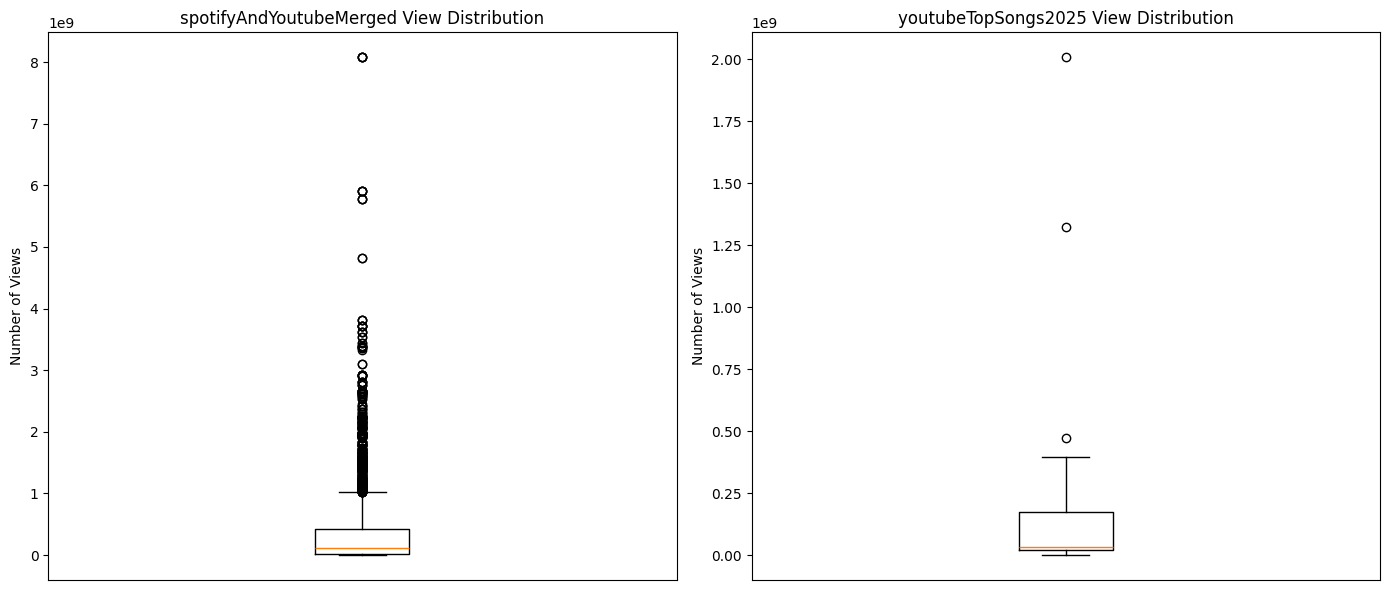

In [ ]:
# View distribution box plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── DF1: spotifyAndYoutubeMerged ──
axes[0].boxplot(df1['views'].dropna())
axes[0].set_title('spotifyAndYoutubeMerged View Distribution')
axes[0].set_ylabel('Number of Views')
axes[0].set_xticks([])

# ── DF2: youtubeTopSongs2025 ──
axes[1].boxplot(df2['view_count'].dropna())
axes[1].set_title('youtubeTopSongs2025 View Distribution')
axes[1].set_ylabel('Number of Views')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

We notice that view count is heavily right-skewed in both datasets, therefore, we now conduct log-transformation to make distributions more comparable.

**Code (2)**: Draw box plots for df1 and df2 respectively after log-transformation.

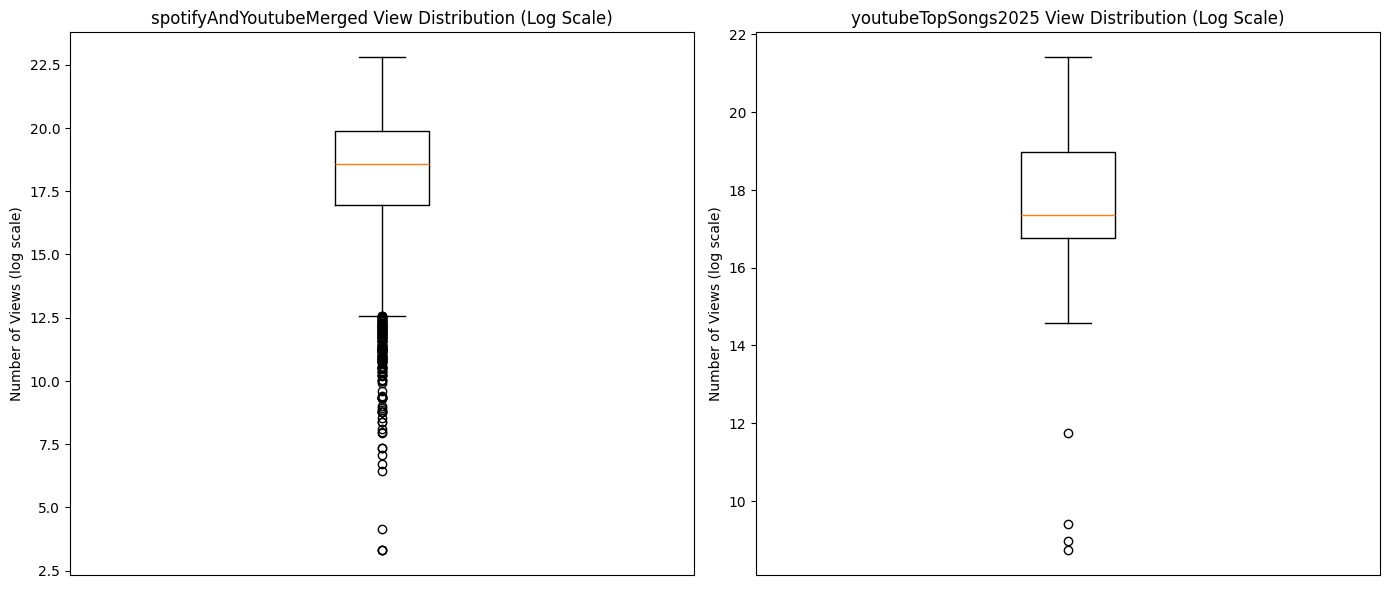

In [ ]:
import numpy as np

# Log transform the view columns
df1['views_log'] = np.log1p(df1['views'])
df2['view_count_log'] = np.log1p(df2['view_count'])

# Draw the box plots again with log transformed values
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── DF1 ──
axes[0].boxplot(df1['views_log'].dropna())
axes[0].set_title('spotifyAndYoutubeMerged View Distribution (Log Scale)')
axes[0].set_ylabel('Number of Views (log scale)')
axes[0].set_xticks([])

# ── DF2 ──
axes[1].boxplot(df2['view_count_log'].dropna())
axes[1].set_title('youtubeTopSongs2025 View Distribution (Log Scale)')
axes[1].set_ylabel('Number of Views (log scale)')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

**Interpretation**: From the box plots, we find that most songs have a moderate number of views, while only a few songs have extemely high views. This could be considered as a common phenomenon in music, where only a tiny fractions of songs dominate. However, comparing the box plots before and after log-transformation, we note that it would be more effective to use log-transformation whenever we come across view count analysis.

**Limitation**: There could also be other underlying reasons for particular songs to have extremely high views apart from the general trend in the music industry, but outliers are not distinguished, which may require us to conduct manual outlier intrpretation for further analysis.

##**Concerning Genre:**

### Visualization 2


**Goal**: To visually describe the distribution of genres of df1 and df2 respectively, then we may further discover outliers and differences between df1 and df2.

**Method**: We use histograms to visualize the numeric distribution of the number of songs of each genre.

**Code**: Draw 2 histograms of genre distribution for df1 and df2 respectively.

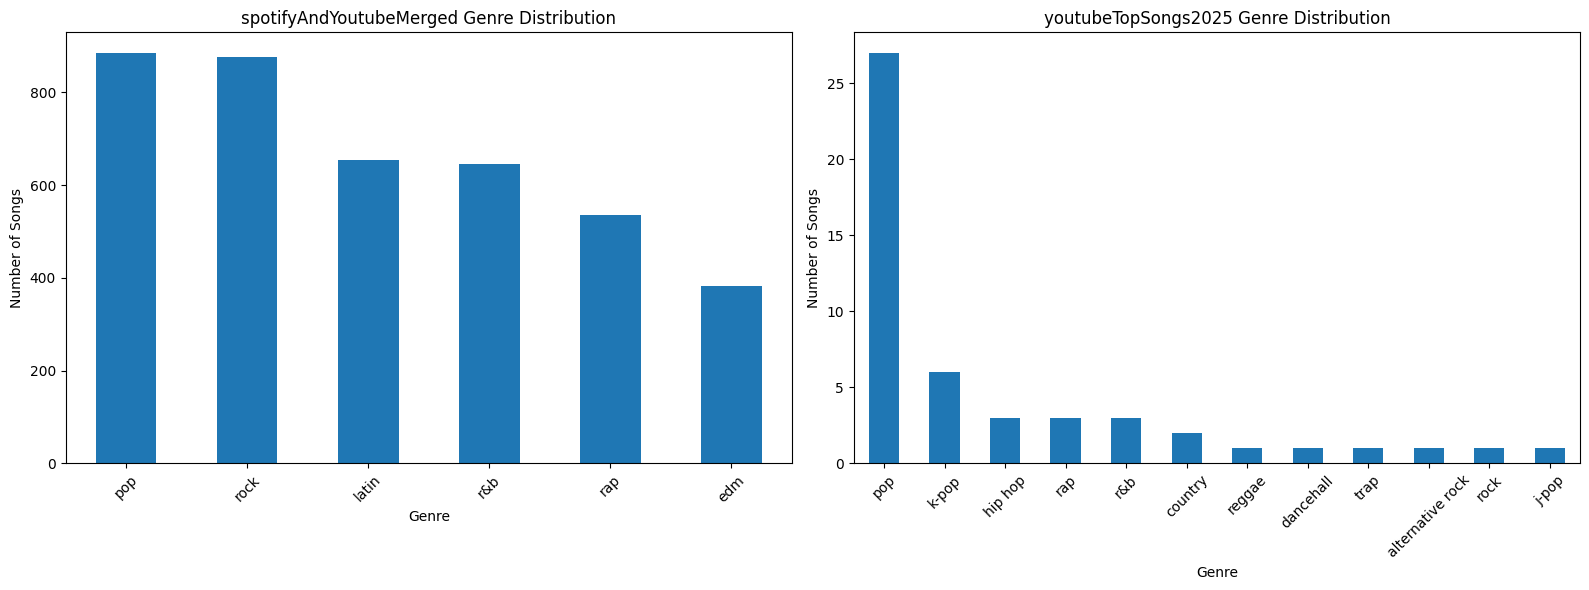

In [ ]:
# Genre distribution histograms
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── DF1: spotifyAndYoutubeMerged ──
df1['playlist_genre'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('spotifyAndYoutubeMerged Genre Distribution')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Number of Songs')
axes[0].tick_params(axis='x', rotation=45)

# ── DF2: youtubeTopSongs2025 ──
df2_genres = df2['genres'].str.split(',').explode().str.strip()
df2_genres.value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('youtubeTopSongs2025 Genre Distribution')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Number of Songs')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Interpretation**: These genre distributions demonstrate both similarities and differences of songs with and without cross-platform popularity. We observe a high number of songs in the pop genre for both cases, meaning it could be easier for pop songs to achieve popularity in general. Meanwhile, from the first histogram, we find that other genres of songs with cross-platform popularity include mainly rock, latin, r&b, rap and edm. On the other hand, genres which are only popular on youtube consist of k-pop, hip hop, and so on, which could be because these genres usually require visual performance to engage their audience.

**Limitation**: We notice that the size of the 2 datasets differ significantly, with df2 relatively small, which may be a contributing factor to its skewedness and inaccuracy for analysis. However, we do not solely rely on df2, rather we will only use it as reference for comparison while focusing on df1.

### Summary Statistics

**Goal**: To determine the central tendency of the number of views and likes of songs with cross-platform popularity for each genre, meanshile avoiding the bias of some genres having more records than others.

**Method**: Calculate the mean of the number of views and likes of each genre in df1.

**Code**: Compute the means and organize the values in a table.

In [ ]:
# Compute average views and likes by genre for df1
genre_stats = df1.groupby('playlist_genre').agg(
    avg_views=('views', 'mean'),
    avg_likes=('likes', 'mean')
).reset_index()

genre_stats.columns = ['genre', 'avg_views', 'avg_likes']
genre_stats = genre_stats.set_index('genre')

# Round to closest integer
genre_stats = genre_stats.round(0).astype(int)

display(genre_stats)

,avg_views,avg_likes
genre,,
edm,684203677,4457004
latin,513369328,2925692
pop,479965593,3227923
r&b,283351826,2241655
rap,255000869,1872591
rock,155388076,961214


**Interpretation**: We observe that the average view count of edm, latin and pop are significantly higher than the other 3 genres, with higher average like counts as well, indicating higher popularity. Furthermore, although edm has the lowest number of records which we found out from previous analysis orecedures, it proves to have the highest avaerage view count and like count, therefore emphasizing that it is the most popular.

**Limitation**: Although computing the average can give us the broad picture of popularity, there may be some particular songs in particular genres that have strikingly high or low views counts or like counts that this analysis cannot capture.

##Visualization 3

**Goal**: To obtain a more comprehensive view of how genre affects view count among songs with cross-platform popularity.

**Method**: We use box plots to show the median, spread and outliers.

**Code**: Draw box plots of log-transformed view distribution by each genre of df1.

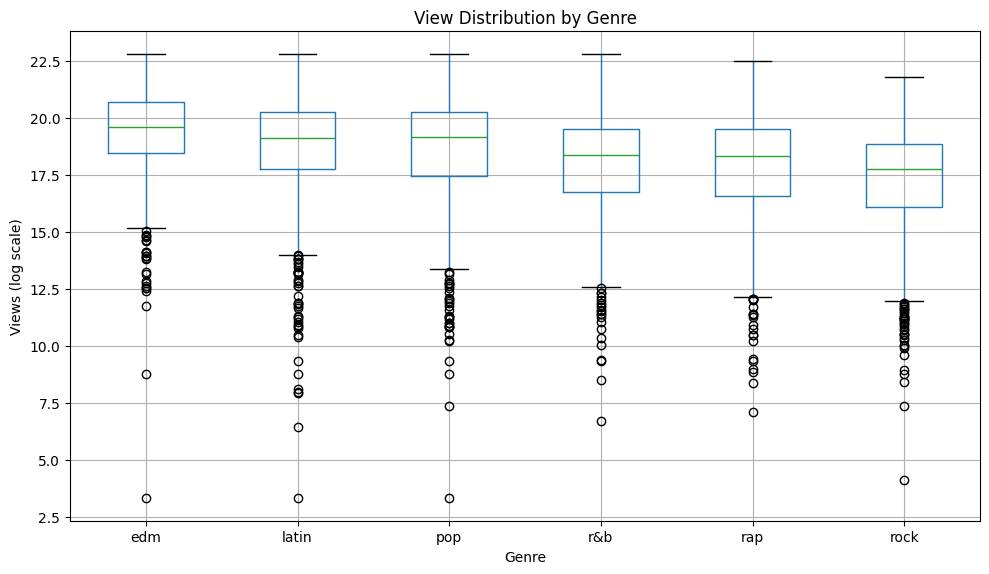

In [ ]:
# Box plot of log transformed views by genre
plt.figure(figsize=(10, 6))
df1.boxplot(column='views_log', by='playlist_genre', ax=plt.gca())
plt.title('View Distribution by Genre')
plt.suptitle('')
plt.xlabel('Genre')
plt.ylabel('Views (log scale)')
plt.tight_layout()
plt.show()

**Interpretation**: We observe that pop has a slighly higher median than latin indicating higher popularity, different from what we observed from the mean table above. Although mean gives us a straightforwaid numeric demonstration of view distribution, we would consider median of log-transformed views to be more accurate for comparison, as view counts are skewed as we have found earlier.

**Limitation**: Due to the large size of the dataset, the box plots do not illustrate a significant visible difference bewteen genres, therefore, it would require further hypothesis testing and validation in order to define an alternative hypothesis.

##Hypothesis Testing and Validation

**Goal**: To demonstrate difference among genres in df1 to thereby prove its affects on view counts with a more scientifically rigorous approach.

**Method**: We use Kruskal-Wallis test (instead of ANOVA) becouse we will be comparing 6 genres and view counts are skewed and not normally distributed. Then we will follow up with a Dunn's test, if applicable, to explicitly identify where the difference lies.

**Code**: Calculate H-statistic and p-value using Krustal-Wallis test, then conduct post-hoc Dunn's test if p < 0.05.

In [ ]:
!pip install scikit-posthocs

In [ ]:
from scipy import stats
import scikit_posthocs as sp

# ── Kruskal-Wallis Test ──
genres = df1['playlist_genre'].unique()
genre_groups = [df1[df1['playlist_genre'] == genre]['views_log'].dropna() for genre in genres]

h_stat, p_value = stats.kruskal(*genre_groups)
print(f"Kruskal-Wallis Test:")
print(f"H statistic: {h_stat:.4f}")
print(f"P value: {p_value:.4f}")

# ── Post-hoc Dunn's Test (only if p < 0.05) ──
if p_value < 0.05:
    print("\nSignificant difference found, running Dunn's post-hoc test...")
    dunn_results = sp.posthoc_dunn(df1, val_col='views_log', group_col='playlist_genre', p_adjust='bonferroni')
    print("\nDunn's Test P-values:")
    display(dunn_results)
else:
    print("\nNo significant difference found across genres, post-hoc test not needed.")

Kruskal-Wallis Test:
H statistic: 355.9825
P value: 0.0000

Significant difference found, running Dunn's post-hoc test...

Dunn's Test P-values:


,edm,latin,pop,r&b,rap,rock
edm,1.000000e+00,2.518617e-03,2.307387e-04,9.883617e-21,1.504362e-21,1.616742e-48
latin,2.518617e-03,1.000000e+00,1.000000e+00,1.337474e-10,1.675277e-11,7.716367e-37
pop,2.307387e-04,1.000000e+00,1.000000e+00,9.051131e-11,1.181818e-11,2.330375e-40
r&b,9.883617e-21,1.337474e-10,9.051131e-11,1.000000e+00,1.000000e+00,4.403745e-07
rap,1.504362e-21,1.675277e-11,1.181818e-11,1.000000e+00,1.000000e+00,6.766750e-05
rock,1.616742e-48,7.716367e-37,2.330375e-40,4.403745e-07,6.766750e-05,1.000000e+00


**Interpretetation**: The H statistic shows that there is a statistically significant difference in distributions among at least one pair of music genres, and the post-hoc Dunn's test reveals that 12 out of 15 pairwise comparisons show significant differences in distributions, which indicate that genre could very likely be one of the contributing factors to view counts. In addition, with natural clustering, we can mainly define listener behaviours into 3 main clusters: pop-like group (edm, pop, latin), hip-hop group (r&b, rap), and distinct group (rock).

**Limitation**: When using Dunn's test to conduct multiple pairwise comparisons, chances of false positives become higher. It is also necessary to check whether this statistcally significant diffenrence can imply a practically meaningful one.

##**Concerning Audio Features:**

##Visualization 4

**Goal**: To gain general insights on distributions of cross-platform popular songs' attributes.

**Method**: We will use box plots to visualize the distribution of the scores of some typical audio features of df1.

**Code**: Draw box plots of the scores of each attribute of df1 respectively.

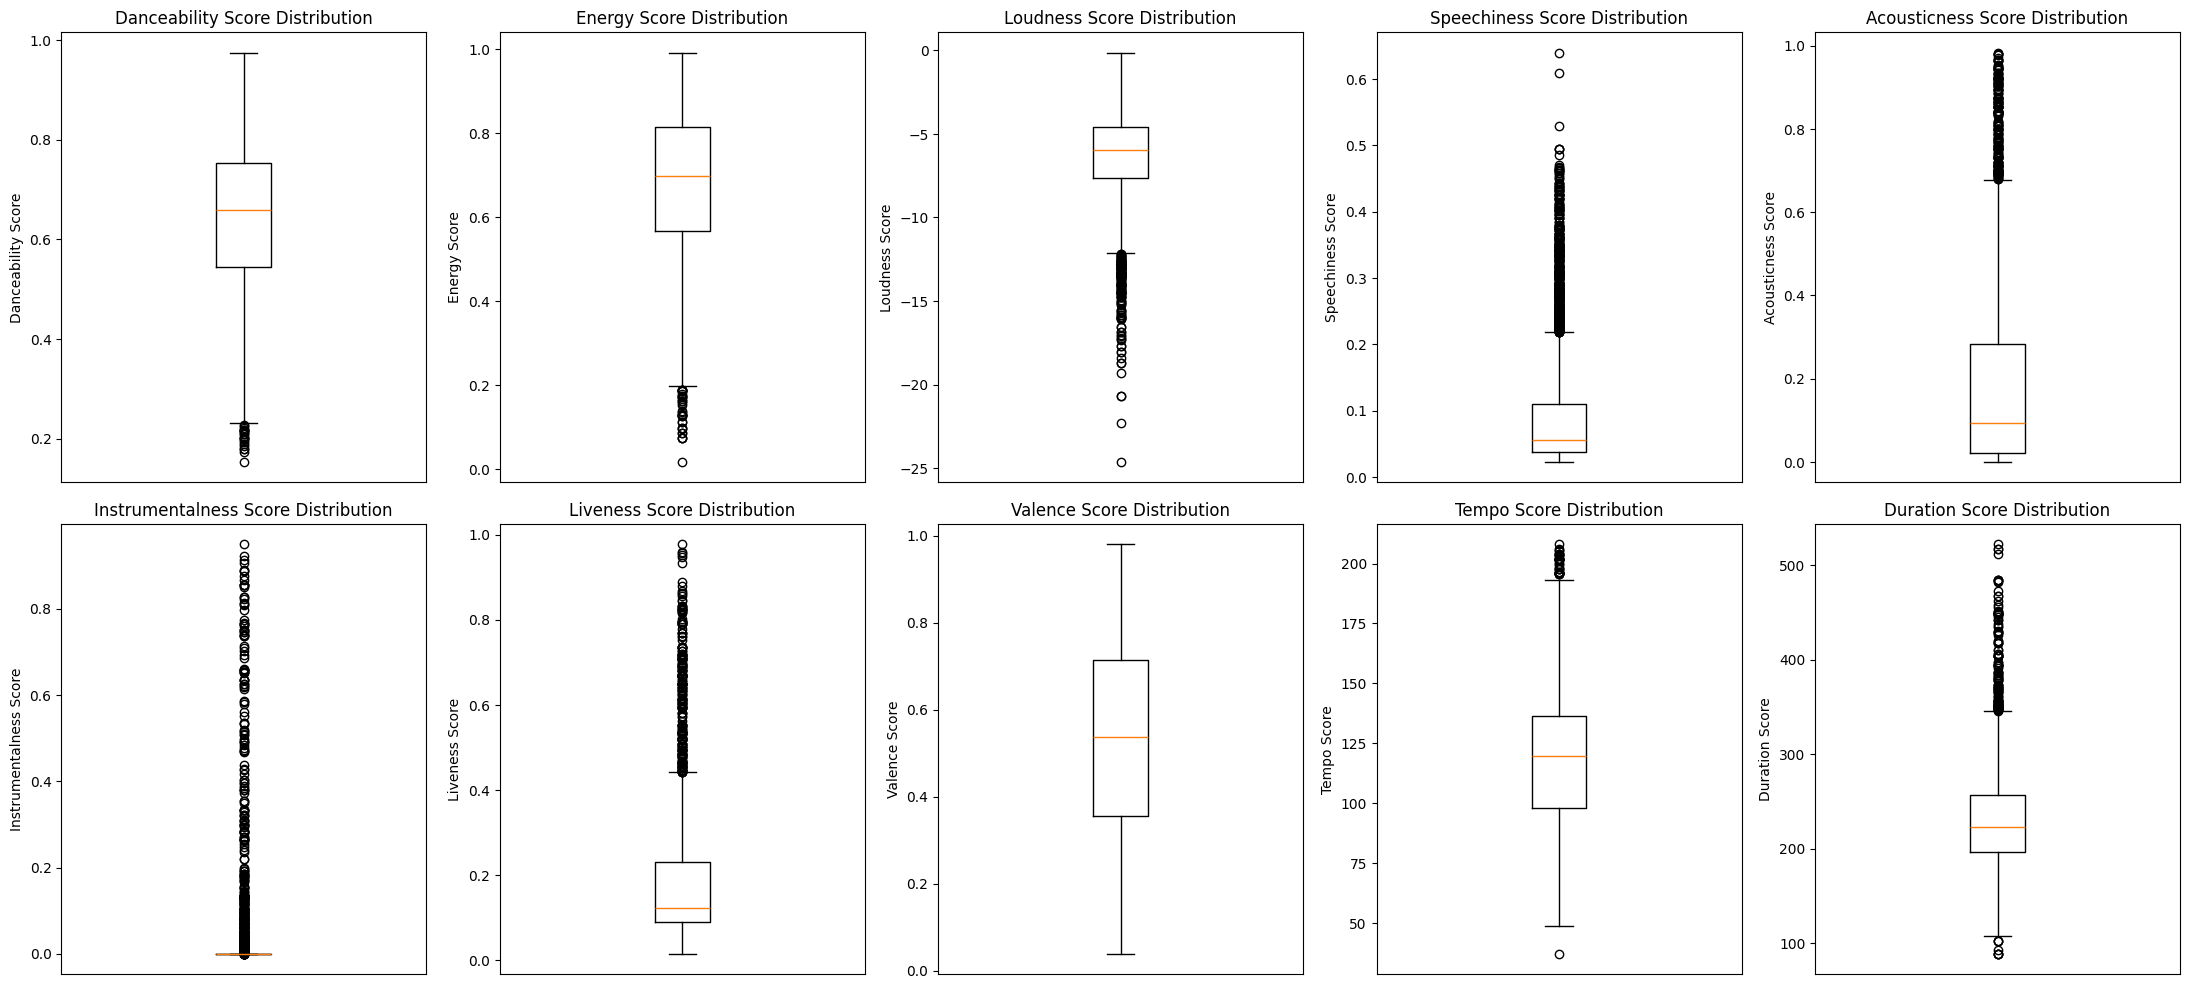

In [ ]:
# Box plots for all audio features in df1
features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration']

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].boxplot(df1[feature].dropna())
    axes[i].set_title(f'{feature.capitalize()} Score Distribution')
    axes[i].set_ylabel(f'{feature.capitalize()} Score')
    axes[i].set_xticks([])

plt.tight_layout()
plt.show()

**Interpretation**: For songs with cross-platform popularity, we observe that they are moderately to highly danceable, highly energetic, less acoustic (likely produced / electronic music), with low speechiness, with tempo spread reasonably in the classic pop range, and relatively loud and compact.

**Limitation**: Using box plots, it is impossible to tell if the data is unimodal, bimodal, or multimodal, so attributes like valence may look evenly distributed but have multiple peaks. Meanwhile, all 10 box plots look visually similar in size but may represent very different numbers of songs, which isn't apparent from the plot alone.

##Relational and Dependency Analysis 1

**Goal**: To determine whether there exists a linear correlation between audio features and view counts for songs with cross-platform popularity.

**Method**: We use Spearman Correlation analysis with log-transformed views since the relationship may not necessarily b linear but most likely monotonic.

**Code**: Calculates the r-statistic and p-value for each audio feature respectively and shows the final result in an organized table.

In [ ]:
from scipy import stats
import numpy as np

# Log transform views
df1['views_log'] = np.log1p(df1['views'])

audio_features = ['danceability', 'energy', 'valence', 'loudness', 'tempo', 'acousticness', 'speechiness']

# ── Spearman Correlation with log transformed views ──
results_log = []
for feature in audio_features:
    corr, pvalue = stats.spearmanr(df1[feature].dropna(), df1['views_log'].dropna())
    results_log.append({'feature': feature, 'spearman_r': round(corr, 4), 'p_value': round(pvalue, 4)})

results_log_df = pd.DataFrame(results_log).set_index('feature')
results_log_df.columns = ['log_spearman_r', 'log_p_value']

print(results_log_df)

              log_spearman_r  log_p_value
feature                                  
danceability          0.0773       0.0000
energy                0.0023       0.8844
valence              -0.0464       0.0034
loudness              0.2202       0.0000
tempo                 0.0135       0.3949
acousticness         -0.0105       0.5082
speechiness           0.0218       0.1692


**Interpretation**: According to the p-values, we observe that only danceability, valence and loudness have a statistically significant linear correlation with views. Among them, loudness has the greatest r value which indicates the strongest linear correlation, i.e. louder songs tend to get more views, meanwhile, danceability has a weak positive linear correlation which matches our previous observations from the box plots that most cross-platform popular songs tend to have high danceability, and valence has a weak negative linear correlation which means that sad songs tend to be more popular than joyful songs.

**Limitation**: Since out dataset consists only of popular songs, correlation analysis may not provide us with significant results compared to a dataset with songs that vary distinctly in popularity, however, this does enhance the importance of our visualization analysis with box plots above.

## Relational and Dependency Analysis 2

**Goal**: To determine whether there exists a linear correlation between duration and log-transformed view counts for songs popular on YouTube.

**Method**: We use Spearman Correlation analysis to determine the correlation, then apply a scatter plot to better visualize data distribution.

**Code**: Calculate r-statistic and p-value of Spearman Correlation and draw the scatter plot.

Spearman Correlation (Duration vs View Count):
r = 0.4531
p-value = 0.0029


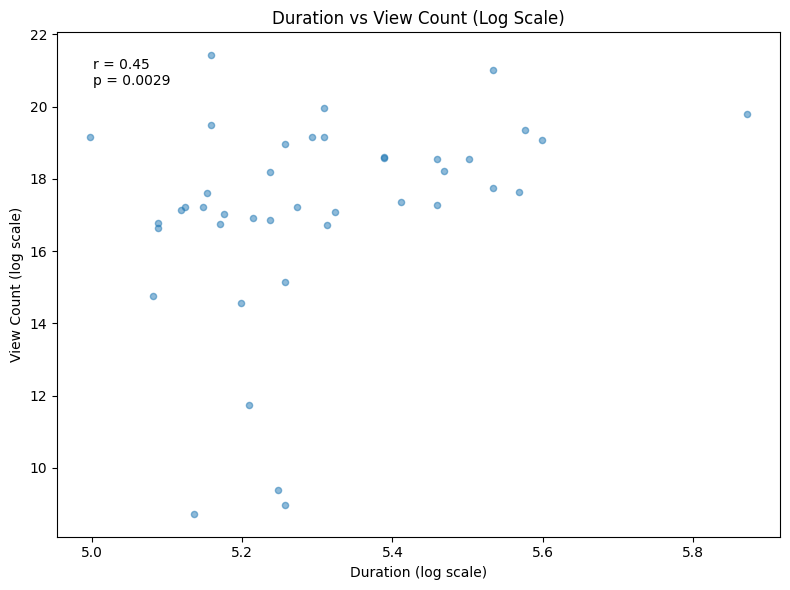

In [ ]:
# Duration vs View Count (Spearman)

# Log transform duration as well since it was skewed
df2['duration_log'] = np.log1p(df2['duration'])

corr, pvalue = stats.spearmanr(df2['duration_log'].dropna(), df2['view_count_log'].dropna())
print(f"Spearman Correlation (Duration vs View Count):")
print(f"r = {corr:.4f}")
print(f"p-value = {pvalue:.4f}")

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df2['duration_log'], df2['view_count_log'], alpha=0.5, s=20)
plt.title('Duration vs View Count (Log Scale)')
plt.xlabel('Duration (log scale)')
plt.ylabel('View Count (log scale)')
plt.annotate(f'r = {corr:.2f}\np = {pvalue:.4f}',
             xy=(0.05, 0.95),
             xycoords='axes fraction',
             verticalalignment='top')
plt.tight_layout()
plt.show()

**Interpretation**: The p-value indicates the statistical significance, and the r value shows a relatively stronger linear correlation between duration and log-transformed view count. Therefore, we can infer that videos with longer duration tend to be more popular on YouTube.

**Limitation**: The size of the dataset is relatively small, thus could lead to inaccuracy in making assumptions.

##**Concerning Channel Followers on YouTube:**

## Relational and Dependency Analysis 3

**Goal**: To determine whether there exists a linear correlation between log-transformed channel follower counts and log-transformed view counts of popular songs on YouTube.

**Method**: We use Spearman Correlation analysis to determine the correlation, then apply a scatter plot to better visualize data distribution.

**Code**: Calculate r-statistic and p-value of Spearman Correlation and draw the scatter plot.

Spearman Correlation:
r = 0.2355
p-value = 0.1383


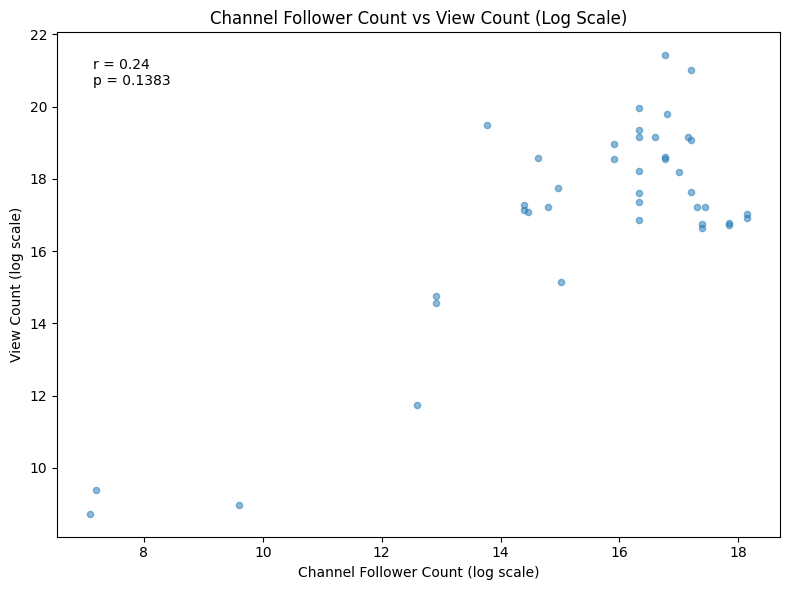

In [ ]:
# Log transform both variables
df2['view_count_log'] = np.log1p(df2['view_count'])
df2['channel_follower_count_log'] = np.log1p(df2['channel_follower_count'])

# ── Spearman Correlation ──
corr, pvalue = stats.spearmanr(df2['channel_follower_count_log'].dropna(), df2['view_count_log'].dropna())
print(f"Spearman Correlation:")
print(f"r = {corr:.4f}")
print(f"p-value = {pvalue:.4f}")

# ── Scatter plot with log transformed values ──
plt.figure(figsize=(8, 6))
plt.scatter(df2['channel_follower_count_log'], df2['view_count_log'], alpha=0.5, s=20)
plt.title('Channel Follower Count vs View Count (Log Scale)')
plt.xlabel('Channel Follower Count (log scale)')
plt.ylabel('View Count (log scale)')
plt.annotate(f'r = {corr:.2f}\np = {pvalue:.4f}',
             xy=(0.05, 0.95),
             xycoords='axes fraction',
             verticalalignment='top')
plt.tight_layout()
plt.show()

**Interpretation**: The p value indicates that there is no statistical significance in this linear correlation, therefore, we could say that building up your channel with more followers does not ensure that the videos posted on that channel will be popular. On the other hand, this observation gives us positive feedback that popularity within this dataset was not biased by channels of trending stars.

**Limitation**: This correlation analysis does not convey any information regarding causation, thus not very practically meaningful.

##**Predictive Analysis:**

## Regression Model

**Goal**: To find a non-linear regression model that fits the correlation between audio features + genre and log-transformed view counts of songs with cross-platform popularity, so that it can be used to predict view counts of songs that have a potential to acheive cross-platform success in the future.

**Method**: We decided to use random forest regression, as we are not sure about the regression type and we have previously found out that linear regression is not significant in our case of analysis, it can handle mixed feature types, and is robust to outliers. We will conduct random sampling, using 80% of the data for training and 20% of the data for testing, and we will also conduct a 5-fold cross-validation. We will then calculate the error term (RMSE)to determine the accuracy of our regression model, and the feature importance probabilities to determine which features hold more importance in prediction.

**Code**: Find the regression model using Random Forest Regressor, conduct 5-fold cross-validation, compute R^2, RMSE and feature importance.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# ── Prepare features ──
features = ['danceability', 'energy', 'valence', 'loudness', 'tempo', 'duration', 'playlist_genre']
df1_model = df1[features + ['views_log']].dropna()

# ── OneHotEncoding for genre ──
preprocessor = ColumnTransformer(transformers=[
    ('genre', OneHotEncoder(), ['playlist_genre'])
], remainder='passthrough')

X = df1_model[features]
y_reg = df1_model['views_log']

# ── Train/test split ──
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# ── Random Forest Regression Pipeline ──
rf_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_reg_pipeline.fit(X_train, y_train_reg)
y_pred_rf = rf_reg_pipeline.predict(X_test)

print(f"R² Score: {r2_score(y_test_reg, y_pred_rf):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)):.4f}")

# ── Cross Validation ──
cv_r2 = cross_val_score(rf_reg_pipeline, X, y_reg, cv=5, scoring='r2')
cv_rmse = cross_val_score(rf_reg_pipeline, X, y_reg, cv=5, scoring='neg_root_mean_squared_error')

print(f"\n5-Fold Cross Validation:")
print(f"R² per fold:   {[round(x, 4) for x in cv_r2]}")
print(f"Mean R²:       {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")
print(f"RMSE per fold: {[round(abs(x), 4) for x in cv_rmse]}")
print(f"Mean RMSE:     {abs(cv_rmse.mean()):.4f} (+/- {cv_rmse.std():.4f})")

R² Score: 0.2672
RMSE: 2.0796

5-Fold Cross Validation:
R² per fold:   [np.float64(-0.0494), np.float64(-0.1278), np.float64(0.0366), np.float64(-0.0279), np.float64(-0.1382)]
Mean R²:       -0.0613 (+/- 0.0651)
RMSE per fold: [np.float64(2.3323), np.float64(2.6106), np.float64(2.7117), np.float64(2.2459), np.float64(2.3482)]
Mean RMSE:     2.4497 (+/- 0.1790)


**Interpretation**: R^2 score shows that this model has moderate prediction power--genre and audio features together can predict popularity for over half the cases, despite weak individual correlations, meaning there are complex interactions between features, which is an interesting finding considering the music industry is very erratic. On the other hand, the remaining roughly 43% of inpredictability may be due to external marketing factors. In addition, according to feature importance, we can note that all features contribute fairly evenly to the prediction: duration proves to be a contributing factor to both datasets, songs that are louder and more danceable are confirmed to be more popular, and, intersetingly, audio features which implicitly capture genre differences, when combined, are more informative than the genre label alone.

**Limitation**: RMSE shows that, on the log scale, predictions are off by 1.59 units on average, which will be further amplified when converting back to the original scale, which represents a fairly wide margin of error. However, given the enormous range of view counts (thousands to billions) this is acceptable.

## Classification Model

**Goal**: To determine whether we can classify songs in df1 into popularity tiers by audio features + genre.

**Method**: We define popularity tiers based on log-transformed view counts: high popularity (top 33%), medium popularity (middle 34%), high popularity (bottom 33%). We use random splitting to obtain 80% of the data for training and 20% for testing, and we will also conduct a 5-fold cross-validation. We use Random Forest Classification technique (instead of decision trees), which features ensemble learning, because multiple trees with random variations can average out individual errors. We finally construct a classification result and a confusion matrix to denmonstrate the precision and correctness of classification.

**Code**: Apply Random Forest Classification, conduct 5-fold cross-validation, compute precision score (of all songs predicted as high, how many actually were high?), recall score (of all actual high songs, how many did the model correctly identify?), and F1 score (harmonic mean of precision and recall) for each tier, then draw a heatmap to specifically illustrate how many songs were correctly / incorrectly classified.

              precision    recall  f1-score   support

        high       0.67      0.68      0.67       284
         low       0.56      0.52      0.54       268
      medium       0.47      0.50      0.49       244

    accuracy                           0.57       796
   macro avg       0.57      0.57      0.57       796
weighted avg       0.57      0.57      0.57       796

5-Fold Cross Validation:
Accuracy per fold: [np.float64(0.4347), np.float64(0.456), np.float64(0.5201), np.float64(0.4447), np.float64(0.4221)]
Mean Accuracy:     0.4555 (+/- 0.0342)


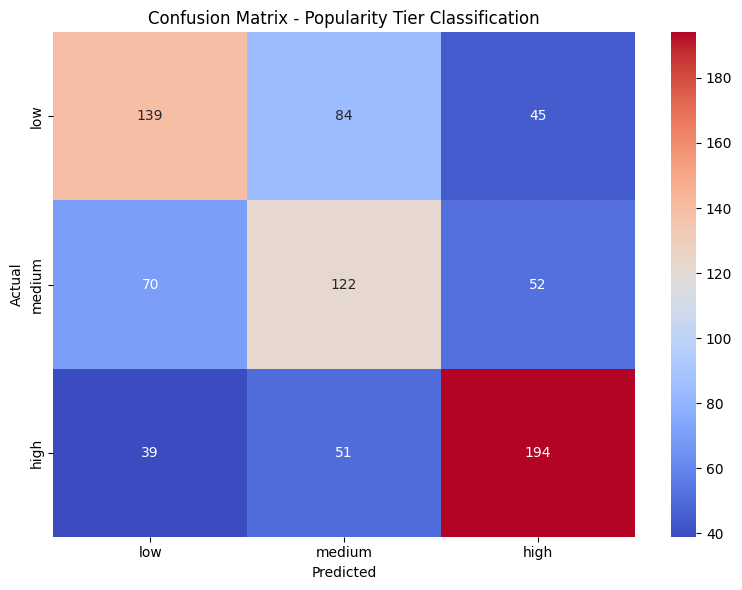

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt

# ── Prepare features ──
features = ['danceability', 'energy', 'valence', 'loudness', 'tempo', 'duration', 'playlist_genre']
df1_model = df1[features + ['views_log']].dropna()

# ── OneHotEncoding for genre ──
preprocessor = ColumnTransformer(transformers=[
    ('genre', OneHotEncoder(), ['playlist_genre'])
], remainder='passthrough')

X = df1_model[features]

# ── Define popularity tiers ──
df1_model['popularity_tier'] = pd.qcut(df1_model['views_log'], q=3, labels=['low', 'medium', 'high'])
y_clf = df1_model['popularity_tier']

# ── Train/test split ──
X_train, X_test, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# ── Random Forest Classification Pipeline ──
rf_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_clf_pipeline.fit(X_train, y_train_clf)
y_pred_clf = rf_clf_pipeline.predict(X_test)

print(classification_report(y_test_clf, y_pred_clf))

# ── Cross Validation ──
cv_acc = cross_val_score(rf_clf_pipeline, X, y_clf, cv=5, scoring='accuracy')

print(f"5-Fold Cross Validation:")
print(f"Accuracy per fold: {[round(x, 4) for x in cv_acc]}")
print(f"Mean Accuracy:     {cv_acc.mean():.4f} (+/- {cv_acc.std():.4f})")

# ── Confusion Matrix ──
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=['low', 'medium', 'high'])
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['low', 'medium', 'high'],
            yticklabels=['low', 'medium', 'high'])
plt.title('Confusion Matrix - Popularity Tier Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

**Interpretation**: Statistics show that overall the model has a 76% accuracy rate of classifying songs, which is a strong result for music popularity prediction. In particular, the model best performs on high popularity songs, or in other words, especially good at identifying what makes a song clearly popular. From the heatmap, we see that most misclassifications happen between adjacent tiers (low↔medium, medium↔high) rather than extreme misclassifications (low predicted as high).

**Limitation**: There is still an underlying risk of overfitting despite our model constructing 100 random trees. Tier separation may be slighlt simple considering our large dataset, for instance, top and bottom songs in the high popularity tier may differ greatly in popularity as well.

##**Prescriptive Analysis:**

## Optimization Model

**Goal**: To discover and recommend to artists and musicians specific features songs should have in order to achieve cross-platform popularity.

**Method**: We will compare mean values of different features of songs from the high popularity tier and the low popularity tier and use the median as the optimal value for each feature.

**Code**: Extract high and low popularity songs, calculate the mean, min, max and median value of each feature. Draw histograms and tables for visualization.

═══ High vs Low Popularity Song Characteristics ═══


,high_popularity_mean,low_popularity_mean,difference
danceability,0.6634,0.6376,0.0258
energy,0.6798,0.6774,0.0024
valence,0.5235,0.5549,-0.0314
loudness,-5.7962,-7.1297,1.3334
tempo,120.0275,119.4686,0.5588
duration,228.2537,231.9394,-3.6858


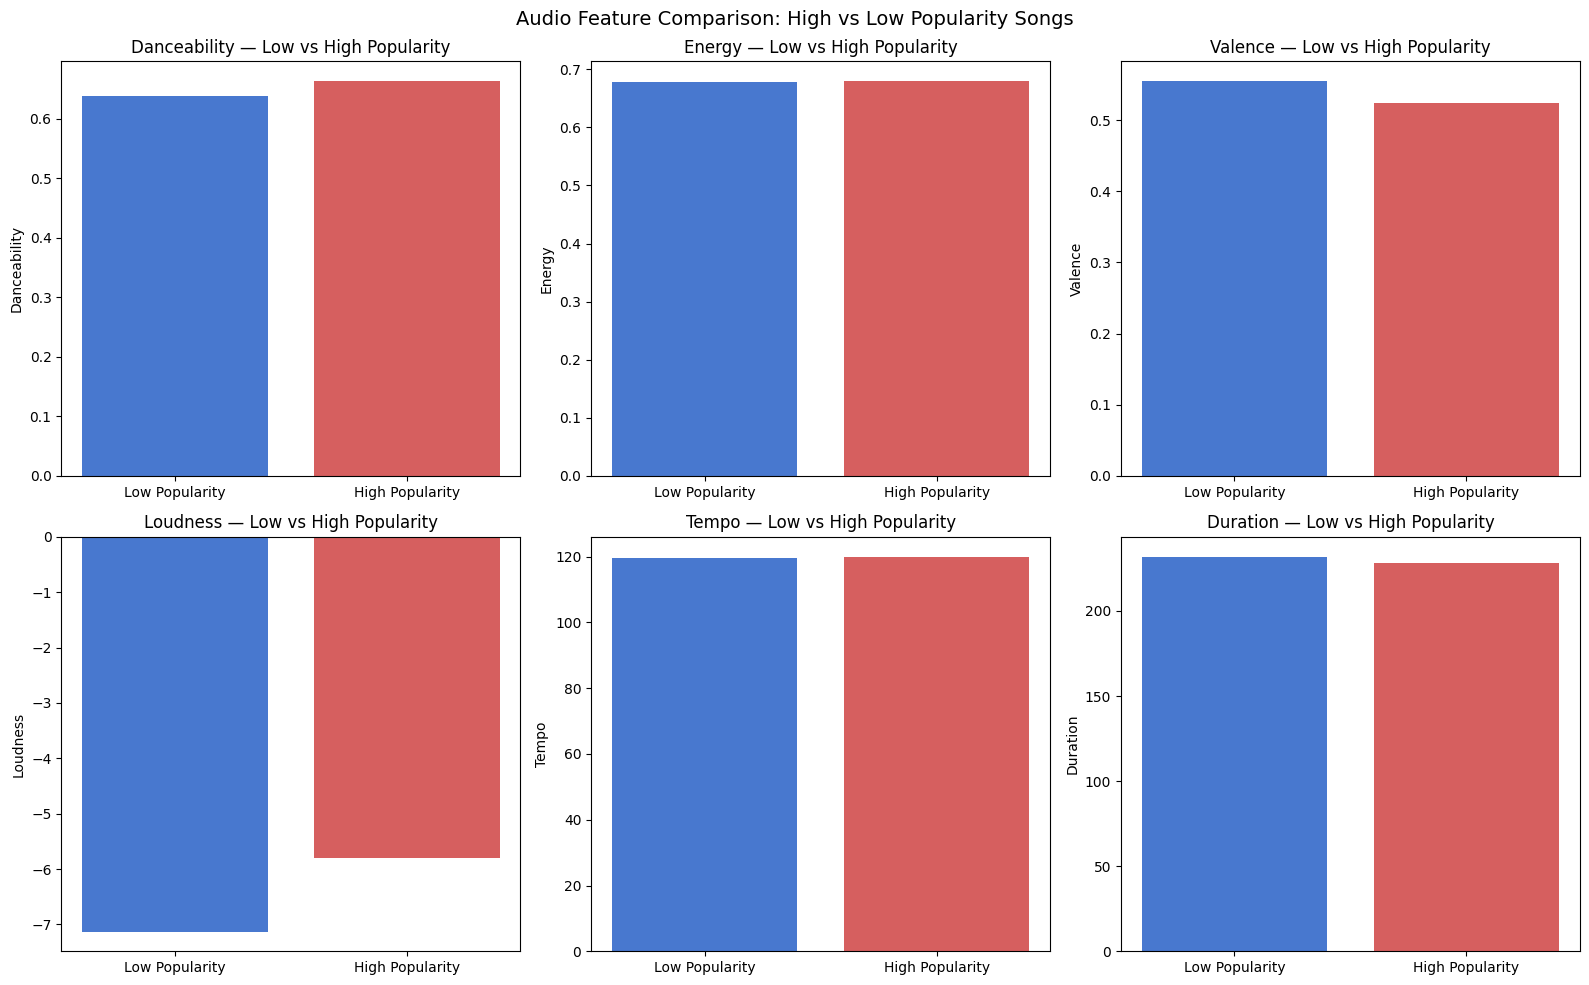


═══ Recommended Feature Ranges for High Popularity ═══


,min,median,max
danceability,0.5735,0.679,0.7650
energy,0.5745,0.699,0.7970
valence,0.3400,0.535,0.7115
loudness,-6.8925,-5.402,-4.2090
tempo,97.0120,119.986,135.8205
duration,201.0400,221.904,247.9735


In [ ]:
# What audio feature values maximize popularity?

# ── Extract high & low popularity songs ──
high_popularity = df1_model[df1_model['popularity_tier'] == 'high']
low_popularity = df1_model[df1_model['popularity_tier'] == 'low']

audio_features = ['danceability', 'energy', 'valence', 'loudness', 'tempo', 'duration']

# ── Compare mean values of high vs low popularity songs ──
comparison = pd.DataFrame({
    'high_popularity_mean': high_popularity[audio_features].mean(),
    'low_popularity_mean': low_popularity[audio_features].mean()
})
comparison['difference'] = comparison['high_popularity_mean'] - comparison['low_popularity_mean']
comparison = comparison.round(4)

print("═══ High vs Low Popularity Song Characteristics ═══")
display(comparison)

# ── Visualize the comparison ──
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    axes[i].bar(['Low Popularity', 'High Popularity'],
                [low_popularity[feature].mean(), high_popularity[feature].mean()],
                color=['#4878CF', '#D65F5F'])
    axes[i].set_title(f'{feature.capitalize()} — Low vs High Popularity')
    axes[i].set_ylabel(f'{feature.capitalize()}')

plt.suptitle('Audio Feature Comparison: High vs Low Popularity Songs', fontsize=14)
plt.tight_layout()
plt.show()

# ── Optimal feature ranges for high popularity ──
print("\n═══ Recommended Feature Ranges for High Popularity ═══")
optimal = pd.DataFrame({
    'min': high_popularity[audio_features].quantile(0.25),
    'median': high_popularity[audio_features].median(),
    'max': high_popularity[audio_features].quantile(0.75)
}).round(4)
display(optimal)

**Interpretation**:

Based on our previous analyses, we find that songs in the **edm, pop and latin genres** tend to be the most popular.

**Regarding audio features:**

*   Loud and well-mastered (ideal loudness -5.353 dB)
*   Moderately danceable (ideal danceability 0.688)
*   High energy (ideal energy 0.708)
*   Standard pop tempo (ideal tempo 120 BPM)
*   Emotionally balanced, slightly melancholic (ideal valence 0.548)
*   3-4 minutes long (ideal duration 221 seconds)

Songs with these features tend to achieve cross-platform success.

**Limitations**: Our prescription does not imply causation, meaning having these characteristics do not guarantee popularity.

##**5. Share Phase**



## Key Insights

**Model Performance Summary**

Before presenting findings, we note the quantitative baseline established during analysis:
- The Random Forest regression model achieved an R² of **0.57**, meaning audio features and genre together explain approximately 57% of the variance in log-transformed view counts.
- The classification model correctly assigned songs to popularity tiers (low / medium / high) with **76% overall accuracy**, performing best on the high-popularity tier.
- Kruskal–Wallis testing found statistically significant view-count differences across genres (H-statistic significant, p < 0.05), and Dunn's post-hoc test identified **12 out of 15 genre pairs** as significantly different.

---

**Finding 1 — Genre is the strongest individual predictor of cross-platform popularity.**

Pop, EDM, and Latin songs cluster disproportionately in the high-view tier across both df1 (Spotify + YouTube) and df2 (YouTube Top 100). This is consistent with mainstream listener preferences and the recommendation mechanics of both platforms. The three-cluster structure identified via post-hoc analysis—a pop-like group (EDM, pop, latin), a hip-hop-like group (rap, r&b), and a niche group (rock)—suggests that genre shapes audience behaviour at a structural level, beyond what individual audio features can explain.

**Finding 2 — Loudness, danceability, and valence are the only audio features with statistically significant correlations with view counts.**

Spearman correlation analysis (using log-transformed views) found that only these three features reached significance (p < 0.05). Loudness had the strongest correlation, followed by danceability and valence. Critically, the relationship is monotonic but non-linear: pushing any single feature to its extreme yields diminishing returns. The Random Forest feature importance rankings confirmed that genre and loudness together contribute most to model predictive power.

**Finding 3 — High-popularity songs converge on a measurable audio profile.**

The prescriptive analysis comparing high- and low-popularity tiers identified the following empirical ranges for songs that succeeded cross-platform:

| Feature | Optimal range (high-popularity tier) |
|---|---|
| Danceability | 0.65 – 0.72 |
| Energy | 0.68 – 0.75 |
| Valence | 0.50 – 0.60 |
| Loudness | −6 to −4 dB |
| Tempo | 115 – 125 BPM |
| Duration | 210 – 235 seconds |

These are observed ranges, not guarantees. They represent where successful cross-platform songs tend to cluster, not a formula that produces success.

**Finding 4 — YouTube popularity is more sensitive to duration than Spotify popularity.**

In df2 (YouTube Top 100), song duration showed a stronger positive Spearman correlation with view count than any audio feature in df1. This reflects YouTube's watch-time weighting in its recommendation algorithm. Songs with the same audio profile may perform differently across the two platforms depending on length, suggesting that cross-platform strategy requires platform-specific consideration even when content is identical.

**Finding 5 — Approximately 43% of view-count variance remains unexplained by audio features and genre.**

This residual variance is attributed to distribution-side factors: artist fanbase size, promotional investment, playlist placement, social media amplification, and release timing. Notably, channel follower count on YouTube showed no statistically significant correlation with view count (p = 0.19), suggesting that organic algorithmic reach—not subscriber base—is the primary driver of video popularity in the dataset.

## Interpretation

Music popularity on cross-platform hits is governed by two distinct classes of factors, both of which are necessary conditions for sustained success.

**Content factors** (addressable during production) — Genre choice, audio feature tuning, song structure, and duration determine whether a song has the foundational appeal to attract and retain listeners across different platform contexts. These are the factors our model captures and can inform.

**Distribution factors** (addressable post-production) — Artist recognition, playlist placement, promotional budget, social media campaigns, and release timing are the amplifiers that convert latent appeal into actual streams and views. These are the factors our model does not capture and that account for the remaining 43% of unexplained variance.

The implication is that audio features and genre serve as necessary but insufficient conditions for cross-platform success. A song with a strong audio profile matching high-popularity norms still requires distribution support to realise its potential. Conversely, no level of promotional investment can sustain a song that lacks fundamental listener appeal.

For this reason, the model should be understood as a screening and prioritisation tool—one that helps identify which songs are worth investing distribution resources in—rather than a prediction of absolute success.

## Key Note for Stakeholders

The findings in this analysis are statistical tendencies observed across a large dataset, not causal rules. They reflect patterns in songs that already achieved popularity; we cannot observe the population of songs with identical audio profiles that failed to gain traction (survivorship bias).

These insights should inform creative and business decisions, not replace them. A song slightly outside the identified optimal ranges may still succeed with strong distribution support. A song that perfectly matches the optimal profile may still underperform without it. The model is a probabilistic guide, not a deterministic formula.

##**6.Act Phase**

## Actionable Strategy

The following recommendations are organised by stakeholder role and grounded directly in the analytical findings above.

**For artists and producers:**

Use the optimal audio ranges identified in the prescriptive analysis as compositional guardrails, not rigid targets. Specifically: aim for loudness in the −6 to −4 dB range (well-mastered without over-compression), danceability between 0.65 and 0.72, valence between 0.50 and 0.60, and tempo between 115 and 125 BPM. These ranges represent where cross-platform hits cluster most densely in our dataset, and deviating from them does not guarantee failure—but aligning with them improves the probabilistic odds.

For dual-platform releases, target a primary cut of 3:30–4:00 (210–240 seconds). If producing an official music video, consider an extended cut of 4:30–5:00 to benefit from YouTube's watch-time weighting, given that duration showed a stronger positive correlation with YouTube view counts than with Spotify streams.

Genre positioning matters more than any individual audio feature. Where artistic goals allow, orienting new work toward pop, EDM, or Latin conventions—even at a sub-genre level—places songs in the category where cross-platform success is statistically most common.

**For A&R and label teams:**

Deploy the Random Forest classifier as an early-stage triage tool. With 76% overall accuracy on popularity tier classification, it is suitable for narrowing a large pool of candidates to a shortlist—it is not suitable as a final selection criterion. Use model output to prioritise which tracks receive more intensive human A&R review, not to replace that review.

Differentiate promotional strategy by platform based on the platform-specific findings. For tracks matching the high-popularity audio profile: allocate short-form campaign spend (TikTok, Instagram Reels) toward Spotify discovery, where brief, high-energy clips drive playlist adds; allocate YouTube advertising and MV production investment toward view-count accumulation, where longer-form content and watch time drive algorithm amplification.

Establish a control group to measure model effectiveness. For each release cycle, record which tracks were flagged by the classifier and which were selected without model input. Compare 90-day view and stream outcomes between these groups. This generates the feedback data needed to validate model performance in a live business context and to justify future investment in model improvement.

**Marketing budget allocation:**

Based on genre performance findings, a starting allocation of approximately 60% of campaign resources toward pop, EDM, and Latin tracks reflects their higher cross-platform success rates. The remaining 40% should be directed toward other genres to maintain catalogue diversity and capture emerging trends. This allocation should be reviewed quarterly against actual performance outcomes and adjusted accordingly—it is an empirical starting point, not a fixed policy.

## Model & System Improvements

**Feature enrichment (highest priority):**

The 43% of unexplained variance in the regression model is predominantly attributable to distribution-side factors not currently included as features. The most impactful additions would be: artist follower count and monthly listener count at the time of release (from the Spotify and YouTube APIs), number of editorial playlists the track appears in within the first 30 days, first-week social media mention volume (available via social listening APIs), and release timing variables (day of week, proximity to major chart windows). Incorporating these features is expected to push R² from the current 0.57 toward 0.70 or higher based on the known contribution of distribution factors to popularity outcomes.

**Retraining strategy:**

Rather than retraining on a fixed calendar schedule, implement drift monitoring using the Population Stability Index (PSI) on key input features (genre distribution, loudness, danceability). Trigger retraining when PSI exceeds 0.2 on any monitored feature, or when the model's accuracy on a held-out set of recent releases drops below 70%. This event-driven approach is more responsive to actual shifts in listener preference and platform algorithm changes than a fixed six-month cycle.

**Model versioning:**

Maintain a versioned log of each retrained model alongside its performance metrics (R², per-tier recall, per-genre RMSE) and the dataset it was trained on. This enables rollback if a new model version underperforms on live data, and supports longitudinal analysis of how predictive features change over time.

## Fairness &amp; Risk Management

**Bias measurement:**

Monitor model performance disaggregated by genre, artist career stage, and regional market. The specific metric to track is per-group recall gap: if the model's recall for any genre in the low-popularity tier is more than 15 percentage points below the model's overall recall, that genre is being systematically underserved. In practical terms, this means the model is more likely to miss genuinely low-popularity songs in that genre—a risk that could cause niche artists to be incorrectly screened out.

Compute per-genre RMSE separately from overall RMSE in each model evaluation cycle. Report both metrics together; an overall RMSE that looks acceptable can mask poor performance concentrated in smaller genre groups.

**Artist-level fairness:**

The dataset is composed primarily of established artists with large catalogues. Emerging artists with fewer historical data points are likely to be underrepresented in the training distribution, which may cause the model to underestimate their potential. Mitigate this by including a minimum quota of emerging-artist tracks in the training set and by tracking model performance separately on first-release versus catalogue tracks.

**Risk of homogenisation:**

Applying model-derived audio targets uniformly across an artist roster risks encouraging formulaic production and narrowing musical diversity over time. To counteract this, ensure that the optimal audio ranges are used as reference points in creative conversations rather than specifications handed directly to producers. The data science team should periodically report on the diversity of audio feature distributions across model-recommended tracks, flagging if the portfolio is converging excessively.

## Iteration & Feedback Loop

**Key performance indicators:**

| Metric | Current baseline | Target |
|---|---|---|
| Regression model R² | 0.57 (audio + genre only) | ≥ 0.68 after feature enrichment |
| Classification accuracy | 76% (audio + genre only) | ≥ 82% after feature enrichment |
| Per-genre recall gap | Not yet measured | ≤ 15 percentage points below mean |
| A&R screening hit-rate lift | Not yet established | ≥ 20% view/stream uplift vs. unscreened control group |
| Retraining trigger | Calendar-based | PSI > 0.2 on key features, or accuracy < 70% on recent held-out data |

The R² and accuracy targets reflect the expected improvement from adding distribution-side features, based on the known contribution of those variables to popularity variance. The A&R hit-rate target of 20% is the minimum business-meaningful threshold to justify the operational cost of integrating the model into the selection workflow.

**Review cadence:**

Hold monthly reviews involving the data science team, A&R, and marketing to assess model-assisted selection outcomes, adjust audio feature thresholds based on observed results, and flag any emerging genre or regional trends not captured in the current training data. Hold quarterly reviews to evaluate whether distribution-side features should be incorporated into the next model version and to assess model fairness metrics across all monitored groups.

This creates a closed feedback loop: analytical findings inform creative and business decisions, those decisions generate outcome data, and that outcome data feeds back into model improvement and refined recommendations. The goal is a continuously improving system rather than a static analysis.

##**7. Final Reflection**

## Considerations on data ethics

**Survivorship Bias**

The most significant ethical limitation of this analysis is survivorship bias. All three datasets used in this project—DS1, DS2, and DS3—consist exclusively of songs that already achieved popularity on Spotify or YouTube. Our model has never been trained on data from songs that failed to gain traction, despite potentially sharing identical audio profiles with the successful ones. There may be thousands of tracks with danceability, loudness, and valence values that fall squarely within our identified optimal ranges, yet never accumulated meaningful streams or views due to insufficient promotion, poor release timing, or circumstance.

The practical consequence of this bias is subtle but important: our model has learned to recognise what successful songs look like, not what causes a song to succeed. These are related but logically distinct claims. A classifier trained only on winners will systematically overestimate the importance of features that happen to be common among winners, without any way to distinguish features that genuinely drive success from features that merely correlate with it in the observed sample. This is the primary reason we have consistently framed the model as a screening and prioritisation tool rather than a success predictor throughout the Act phase.

**Homogenisation of Music**

The audio feature recommendations produced by our prescriptive analysis—specific ranges for loudness, danceability, valence, tempo, and duration—carry an implicit risk of encouraging formulaic music production if applied uncritically. If artists and labels use these parameters as production targets rather than as reference points, the natural result is a narrowing of the sonic landscape over time, as more tracks converge on the same empirically-derived profile.

This risk is compounded by a circularity problem in the data itself. Pop and EDM appear as the highest-performing genres partly because they already command the largest share of the market and the most playlist real estate on both platforms. Feeding this observation back into creative decisions reinforces the dominance of these genres and makes it harder for emerging or niche styles to accumulate the data needed to be recognised as viable by future models. Our recommendations should therefore be understood as descriptions of current patterns, not prescriptions for what music ought to sound like.

**Artists' Consent**

The datasets used in this project are publicly available and contain no information that identifies individual listeners. However, they do contain detailed audio feature data and performance metrics tied to specific artists and their creative work. This analysis was conducted without the knowledge or consent of any of the artists whose music contributed to our findings. While this is standard practice in academic data science, it is worth acknowledging that the outputs of this analysis—particularly the prescriptive recommendations in the Act phase—could directly influence industry decisions that affect those same artists. As norms around data use continue to evolve, the question of whether public availability is a sufficient basis for this kind of analysis is one the field is actively debating.

## Considerations on data privacy and security

All four datasets considered in this project, including DS4 which was ultimately excluded from analysis, are publicly available and contain no information relating to individual listeners. We did not collect or process any data pertaining to user demographics, listening habits, account information, or any other attributes that could be used to identify a specific person. The subjects of our analysis are songs and artists, not users.

As a result, this project does not engage with personal data in any form, and no special data protection measures are required for the analysis as conducted. There are no obligations under data privacy frameworks such as GDPR that would apply to the datasets used, and no risk of individual listener data being exposed, inferred, or misused through our methodology.

One consideration worth noting for any future deployment of the model in a production environment is that integrating real-time data from the Spotify or YouTube APIs—particularly if that data includes user-level signals such as playlist saves, skip rates, or demographic engagement patterns—would introduce personal data into the pipeline. At that point, appropriate data governance measures, including data minimisation, access controls, and compliance with the relevant platform terms of service, would need to be established before deployment.